# ClaimStruct

## Clasificación y Estructuración Automática de Reclamos Bancarios
Proyecto Final – Materia Deep Learning

Especialización en Ciencia de Datos e Inteligencia Artificial

Autores:
Leticia Colombo y Jeasmine Ñahui



## Introducción

Este notebook corresponde al proyecto final de la materia Deep Learning, en el marco de la Especialización en Ciencia de Datos e Inteligencia Artificial.

El objetivo del proyecto es desarrollar un sistema basado en modelos de lenguaje tipo Transformer capaz de clasificar automáticamente reclamos bancarios redactados en texto libre y extraer información relevante en formato estructurado. La propuesta aborda una problemática real vinculada a la clasificación manual de conversaciones que ingresan por canales digitales como chat, aplicación móvil y web, proceso que actualmente requiere intervención humana y presenta desafíos en términos de eficiencia operativa, consistencia y trazabilidad.

La solución propuesta no funciona como chatbot ni genera respuestas automáticas al cliente. Su propósito es actuar como un motor interno de clasificación y estructuración que permita identificar la intención principal del reclamo, detectar entidades relevantes como producto y motivo, y generar registros estructurados que faciliten el análisis posterior y el enrutamiento hacia equipos humanos.

Debido a restricciones de confidencialidad y acceso a información sensible, el dataset utilizado es sintético y fue generado con apoyo de modelos de lenguaje. Se diseñó cuidadosamente para asegurar diversidad lingüística, representación de los principales tipos de reclamo y balance entre clases, permitiendo así realizar entrenamiento y evaluación de modelos de manera rigurosa.

Primero se desarrolla el análisis exploratorio de datos, etapa clave para comprender la estructura del dataset, su distribución y sus características principales antes de avanzar hacia el modelado.

Aclaración: Durante la ejecución se le va a pedir ingresar el claimstruct_multitable_v2.zip, ingresarlo utilizando la utilidad de cargar archivo

## Importacion de librerías

De existir un error al instalar las dependencias des-comentar las siguientes lineas

In [141]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import defaultdict
from sklearn.model_selection import StratifiedShuffleSplit

import os
import re
import zipfile
import json
import random
import textwrap

warnings.filterwarnings("ignore")

## Configuración

In [142]:
@dataclass
class Config:
    # --- Configuracion de visualizacion ---
    palette: list = field(default_factory=lambda: [
        '#a5c4beff',  # verde salvia suave
        '#ffc0c0ff',  # rosa pastel
        '#3f5a6bff',  # azul petróleo
        '#f38681ff',  # coral suave
        '#00c3b1ff',  # turquesa vibrante
        '#6c8ea3ff',  # azul grisáceo medio
        '#b8a1c9ff',  # lavanda apagada
        '#f2b880ff',  # durazno cálido
        '#7bbfa5ff',  # verde menta medio
        '#d97d54ff',  # terracota suave
    ])
    bg_color: str = "#f7ecdcff" # Color de fondo de las figuras
    fig_w: int = 8             # Ancho de las figuras en pulgadas
    fig_h: int = 4              # Alto de las figuras en pulgadas
    dpi: int = 130              # Resolucion de las figuras
    sample_pairplot: int = 2000 # Cantidad de muestras para el pairplot (evita graficos lentos)
    seed: int = 42              # Semilla para reproducibilidad
    bert_model_name: str = "dccuchile/bert-base-spanish-wwm-cased" # Modelo BERT a utilizar para entrenamiento
    n_augments: int = 3              # Numero de variantes por conversación para estrategia de augmentation

# Instanciar configuracion global
cfg = Config()

# Fijar semillas para garantizar reproducibilidad en NumPy
np.random.seed(cfg.seed)
random.seed(cfg.seed)

In [143]:
sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": cfg.bg_color,
        "axes.facecolor": cfg.bg_color
    }
)

## Metodos utilitarios

In [144]:
def anonimizar_texto(texto: str) -> str:
    """
    Reemplaza menciones al banco por un token anonimo.
    Cubre variantes: itau, Itau, itaú, Itaú, ITAU, banco itau,
    Itaú: (seguido de dos puntos) etc.
    """
    patrones = [
        r"[Bb]anco\s+[Ii]ta[uú][eé]?s?\s*:?",   # banco itau, Banco Itaú:
        r"[Ii]ta[uú]\s+[Bb]anco\s*:?",            # itau banco:
        r"[Ii]ta[uú][eé]?s?\s*:?",                # itau, Itaú, itaues, Itaú:
        r"ITAU[EÉ]?S?\s*:?",                       # ITAU, ITAUES, ITAU:
    ]

    patron_combinado = "|".join(patrones)

    return re.sub(patron_combinado, "[BANCO]", texto)

#### Helpers genericos de visualizacion

In [145]:
def plot_barh(series: pd.Series, ax: plt.Axes, title: str,
              xlabel: str = "Frecuencia", palette: str = "viridis",
              top_n: int = 20, color: str = None,
              color_map: dict = None) -> None:
    """Barras horizontales a partir de un value_counts o Series ordenado."""
    data = series.head(top_n)

    if color_map:
        # Color distinto por categoria usando mapa compartido
        colors = [color_map[idx] for idx in data.index]
    elif color:
        # Color unico para todas las barras
        colors = color
    else:
        # Color distinto por posicion usando palette
        colors = sns.color_palette(palette, len(data))

    data.plot.barh(ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

In [146]:
def plot_hist(series: pd.Series, ax: plt.Axes, title: str,
              xlabel: str = "", bins: int = 60, log: bool = False, color: str = "steelblue") -> None:
    """Histograma con linea de mediana."""
    series.hist(bins=bins, ax=ax, color=color, edgecolor="white", log=log)
    ax.axvline(series.median(), color="red", ls="--", lw=1.2, label=f"Mediana={series.median():.0f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

In [147]:
def plot_heatmap(ct: pd.DataFrame, ax: plt.Axes, title: str,
                 fmt: str = "d", cmap: str = "YlOrRd") -> None:
    """Heatmap generico sobre una tabla de contingencia o correlacion."""
    sns.heatmap(ct, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(title)

In [148]:
def plot_heatmap_corr(corr: pd.DataFrame, ax: plt.Axes, title: str,
                      cmap: str = "RdBu_r") -> None:
    """Heatmap triangular para matrices de correlacion."""
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title)

In [149]:
def plot_stacked_pct(ct: pd.DataFrame, ax: plt.Axes, title: str,
                     cmap: str = "tab10") -> None:
    """Barras horizontales apiladas al 100% a partir de un crosstab."""
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Si cmap es una lista de colores, crear un colormap desde ella
    if isinstance(cmap, list):
        from matplotlib.colors import ListedColormap
        cmap = ListedColormap(cmap)

    ct_pct.plot.barh(stacked=True, ax=ax, colormap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Porcentaje")
    ax.invert_yaxis()
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

### Helpers de datos

In [150]:
def extract_zip(zip_path: str, extract_dir: str) -> None:
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)


def safe_read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

In [151]:
def mostrar_conversaciones_random(df, n_conversations=3):
    conv_ids = df["conversation_id"].dropna().unique()

    selected_convs = random.sample(
        list(conv_ids),
        min(n_conversations, len(conv_ids))
    )

    for cid in selected_convs:
        df_conv = df[df["conversation_id"] == cid] \
            .sort_values("timestamp_offset_sec")

        # Tomar reason_code_primary (puede repetirse dentro de la conv)
        reason = df_conv["reason_code_primary"].dropna().iloc[0] \
            if "reason_code_primary" in df_conv.columns else "UNKNOWN"

        print("\n" + "="*80)
        print(f"CONVERSATION ID: {cid}")
        print(f"REASON CODE: {reason}")
        print("="*80)

        for _, row in df_conv.iterrows():

            print(f"[{row['speaker'].upper()}] {row['text']}")
            print()

        print("="*80 + "\n")

In [152]:
def check_col(df: pd.DataFrame, col: str) -> bool:
    """Verifica que la columna exista y tenga datos no nulos."""
    return col in df.columns and df[col].notna().any()

In [153]:
def crosstab_safe(df: pd.DataFrame, row: str, col: str) -> Optional[pd.DataFrame]:
    """Crosstab solo si ambas columnas tienen datos."""
    if check_col(df, row) and check_col(df, col):
        return pd.crosstab(df[row], df[col])
    return None

In [154]:
def agregar_por_conversacion(messages: pd.DataFrame, entities: pd.DataFrame) -> pd.DataFrame:
    """Calcula metricas agregadas por conversacion: mensajes, palabras, duracion, entidades."""
    # Agrupa los mensajes por conversacion y calcula metricas de texto y duracion
    msg_agg = messages.groupby("conversation_id").agg(
        # Cantidad total de mensajes en la conversacion
        n_msgs=("message_id", "size"),
        # Total de palabras sumando las palabras de cada mensaje
        total_words=("text", lambda x: x.astype(str).str.split().str.len().sum()),
        # Total de caracteres sumando la longitud de cada mensaje
        total_chars=("text", lambda x: x.astype(str).str.len().sum()),
        # Duracion en segundos
        duracion_sec=("timestamp_offset_sec", lambda x: x.max() - x.min()),
    ).reset_index()

    # Agrupa las entidades por conversacion y calcula metricas de entidades
    ent_agg = entities.groupby("conversation_id").agg(
        # Cantidad total de entidades detectadas en la conversacion
        n_entities=("entity_type", "size"),
        # Cantidad de tipos de entidades distintos (ej: PERSON, ORG, DATE...)
        n_entity_types=("entity_type", "nunique"),
    ).reset_index()

    # Une ambas tablas por conversation_id usando left join para conservar
    # todas las conversaciones, incluso las que no tienen entidades
    df = msg_agg.merge(ent_agg, on="conversation_id", how="left")

    # Las conversaciones sin entidades quedan con NaN tras el merge,
    # se reemplazan por 0
    df[["n_entities", "n_entity_types"]] = df[["n_entities", "n_entity_types"]].fillna(0).astype(int)

    return df

In [155]:
def print_dataframe_info(name: str, df: pd.DataFrame) -> None:
    """
    Imprime información estructural básica de un DataFrame.
    """
    print("\n" + "=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumnas:")
    print(list(df.columns))

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nValores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))

    print("\nMemoria aproximada en MB:")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 3))

    print("\nEstadísticas descriptivas:")
    print(df.describe(include="all"))

In [156]:
def print_multiple_dataframes_info(dfs: dict) -> None:
    """
    Recibe un diccionario {nombre: dataframe} y muestra info para cada uno.
    """
    print("===== INFORMACIÓN GENERAL =====")
    for name, df in dfs.items():
        print_dataframe_info(name, df)

In [157]:
def compute_tsne(texts: pd.Series, n_pca: int = 50,
                 n_sample: int = 2000, seed: int = 42,
                 max_features: int = 5000) -> Tuple[np.ndarray, np.ndarray, PCA]:
    """Pipeline TF-IDF → PCA → t-SNE. Retorna coordenadas 2D, índices del sample y el PCA."""
    tfidf = TfidfVectorizer(max_features=max_features, sublinear_tf=True)
    X = tfidf.fit_transform(texts)

    pca = PCA(n_components=n_pca, random_state=seed)
    X_pca = pca.fit_transform(X.toarray())

    n_s = min(n_sample, len(texts))
    idx = np.random.choice(len(texts), n_s, replace=False)

    tsne = TSNE(n_components=2, random_state=seed, perplexity=30)
    X_2d = tsne.fit_transform(X_pca[idx])

    return X_2d, idx, pca

def plot_tsne_scatter(X_2d: np.ndarray, labels_arr: np.ndarray,
                      ax: plt.Axes, title: str,
                      palette: list, s: int = 12, alpha: float = 0.6,
                      mask: np.ndarray = None) -> None:
    """Scatter plot coloreado por categoría."""
    if mask is None:
        mask = np.ones(len(labels_arr), dtype=bool)

    unique = sorted(set(labels_arr[mask]))
    for i, cat in enumerate(unique):
        m = (labels_arr == cat) & mask
        if m.any():
            ax.scatter(X_2d[m, 0], X_2d[m, 1],
                       label=cat, s=s, alpha=alpha,
                       color=palette[i % len(palette)])

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

## Montado de dataset

El siguiente codigo comentado es para uso interno de Leticia y Jeasmine

In [158]:
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     print("Drive montado correctamente.")

#     zip_path = "/content/drive/MyDrive/CIENCIA_DE_DATOS_UTEC/Trabajo_final/Deep Learning/claimstruct_multitable_v2.zip"
#     extract_dir = "/content/claimstruct_multitable_v2"
#     extract_zip(zip_path, extract_dir)
# except:
#     print("No se ejecuta en Colab o Drive ya está montado.")

In [159]:
"""## Carga del dataset

El dataset se puede cargar de tres formas:
1. **Upload interactivo en Colab**: se muestra un diálogo para subir el ZIP.
2. **Path local**: si el ZIP ya está en el directorio de trabajo (ejecuciones previas o entorno local).
3. **Google Drive**: si se monta Drive manualmente, ajustar `ZIP_FILENAME` al path correspondiente.
"""

ZIP_FILENAME = "claimstruct_multitable_v2.zip"
extract_dir = "/content/claimstruct_multitable_v2"

if not os.path.exists(ZIP_FILENAME):
    try:
        from google.colab import files
        print(f"No se encontró '{ZIP_FILENAME}' en el directorio actual.")
        print("Por favor, suba el archivo ZIP del dataset.")
        uploaded = files.upload()
        # Si el usuario subió un archivo con nombre diferente, renombrar
        uploaded_name = list(uploaded.keys())[0]
        if uploaded_name != ZIP_FILENAME:
            os.rename(uploaded_name, ZIP_FILENAME)
            print(f"Archivo renombrado: '{uploaded_name}' → '{ZIP_FILENAME}'")
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró '{ZIP_FILENAME}' en el directorio de trabajo. "
            "Coloque el archivo ZIP en el directorio actual o ejecute en Google Colab."
        )

extract_zip(ZIP_FILENAME, extract_dir)
print(f"Dataset extraído en: {extract_dir}")

Dataset extraído en: /content/claimstruct_multitable_v2


In [160]:
conversations_path = os.path.join(extract_dir, "conversations.csv")
messages_path = os.path.join(extract_dir, "messages.csv")
labels_path = os.path.join(extract_dir, "labels.csv")
entities_path = os.path.join(extract_dir, "entities.csv")

conversations = safe_read_csv(conversations_path)
messages = safe_read_csv(messages_path)
labels = safe_read_csv(labels_path)
entities = safe_read_csv(entities_path)

In [161]:
print("Shapes:")
for n, df in [("messages", messages), ("labels", labels),
              ("entities", entities), ("conversations", conversations)]:
    print(f"  {n}: {df.shape}")

Shapes:
  messages: (46713, 5)
  labels: (8000, 13)
  entities: (16502, 9)
  conversations: (8000, 10)


## Análisis de Datos

### Sanity Check e Integridad

In [162]:
print_multiple_dataframes_info({
    "Conversations": conversations,
    "Messages": messages,
    "Labels": labels,
    "Entities": entities
})

# ─── Resumen general (dinámico) ───
n_conv = len(conversations)
n_msgs = len(messages)
n_ents = len(entities)
n_labs = len(labels)
msgs_per_conv = n_msgs / n_conv
ents_per_conv = n_ents / n_conv
mem_total_mb = sum(
    df.memory_usage(deep=True).sum()
    for df in [conversations, messages, labels, entities]
) / 1024**2

n_unique_texts = messages["text"].nunique() if "text" in messages.columns else 0
top_text = messages["text"].value_counts().head(1)
top_text_name, top_text_count = top_text.index[0], top_text.values[0]

null_intent_sec = labels["intent_secondary"].isna().sum() if "intent_secondary" in labels.columns else 0
null_pct = null_intent_sec / n_labs * 100

top_channel = conversations["channel"].value_counts().head(1)
ch_name, ch_count = top_channel.index[0], top_channel.values[0]
ch_pct = ch_count / n_conv * 100

top_intent = labels["intent_primary"].value_counts().head(1)
int_name, int_count = top_intent.index[0], top_intent.values[0]
int_pct = int_count / n_conv * 100

n_canales = conversations["channel"].nunique()
n_intents = labels["intent_primary"].nunique()

speaker_counts = messages["speaker"].value_counts()
customer_count = speaker_counts.get("customer", 0)
agent_count = speaker_counts.get("agent", 0)
customer_pct = customer_count / n_msgs * 100
agent_pct = agent_count / n_msgs * 100

===== INFORMACIÓN GENERAL =====

CONVERSATIONS

Shape:
(8000, 10)

Columnas:
['conversation_id', 'created_at', 'channel', 'language', 'customer_segment', 'country', 'product_hint', 'is_synthetic', 'dataset_version', 'split']

Tipos de datos:
conversation_id     object
created_at          object
channel             object
language            object
customer_segment    object
country             object
product_hint        object
is_synthetic          bool
dataset_version     object
split               object
dtype: object

Valores nulos por columna:
conversation_id     0
created_at          0
channel             0
language            0
customer_segment    0
country             0
product_hint        0
is_synthetic        0
dataset_version     0
split               0
dtype: int64

Memoria aproximada en MB:
4.07

Estadísticas descriptivas:
       conversation_id           created_at channel language customer_segment  \
count             8000                 8000    8000     8000            

El dataset generado está estructurado en cuatro tablas bien diferenciadas:
- conversations (8000 filas)
- messages (46.713 filas)
- labels (8000 filas)
- entities (16.502 filas)


La unidad principal de análisis es la conversaciòn, mientras que el texto está fragmentado en múltiples mensajes por conversación.


Desde el punto de  vista de  calidad de los datos, es un dataset limpio ya que no hay valores nulos en conversations, messages ni entities, si hay en labels pero esto es porque es opcional.

In [163]:
print(f"\n{'='*65}")
print("RESUMEN GENERAL DEL DATASET")
print(f"{'='*65}")
print(f"\n  Volumen: {n_conv:,} conversaciones | {n_msgs:,} mensajes | "
      f"{n_ents:,} entidades | {n_labs:,} labels")
print(f"  Promedios: {msgs_per_conv:.1f} msgs/conv | {ents_per_conv:.1f} ents/conv")
print(f"  Memoria total: ~{mem_total_mb:.1f} MB")
print(f"\n  Textos únicos en mensajes: {n_unique_texts:,} de {n_msgs:,} "
      f"(más frecuente: \"{top_text_name}\" con {top_text_count:,} ocurrencias)")
print(f"  intent_secondary nulos: {null_intent_sec:,} ({null_pct:.1f}%) — no viable para entrenamiento")
print(f"\n  Canales: {n_canales} | dominante: {ch_name} ({ch_count:,}, {ch_pct:.1f}%)")
print(f"  Intents: {n_intents} | dominante: {int_name} ({int_count:,}, {int_pct:.1f}%)")
print(f"  Speakers: customer {customer_count:,} ({customer_pct:.1f}%) | "
      f"agent {agent_count:,} ({agent_pct:.1f}%)")
print(f"{'='*65}")

print("""\n**Resumen general** (ver estadísticas computadas arriba)

El dataset es 100% sintético, monolingue en español y geográficamente concentrado
en Uruguay. Las tablas conversations, messages y entities no presentan valores nulos.
La excepción es labels, donde intent_secondary tiene un porcentaje alto de nulos,
lo que la hace no viable para entrenamiento; se utiliza exclusivamente intent_primary
como objetivo de clasificación.

El alto reuso de frases en los mensajes es característico de datos sintéticos y
es un factor a monitorear durante el entrenamiento, ya que podría afectar la
capacidad de generalización del modelo.

Los campos severity, fraud_risk, outcome y routing_queue están disponibles como
candidatos para futuras tareas multitask, y el campo confidence de entities
permitiría filtrar por umbral de calidad si se detecta ruido.
""")


RESUMEN GENERAL DEL DATASET

  Volumen: 8,000 conversaciones | 46,713 mensajes | 16,502 entidades | 8,000 labels
  Promedios: 5.8 msgs/conv | 2.1 ents/conv
  Memoria total: ~29.4 MB

  Textos únicos en mensajes: 3,271 de 46,713 (más frecuente: "Gracias." con 1,655 ocurrencias)
  intent_secondary nulos: 6,549 (81.9%) — no viable para entrenamiento

  Canales: 6 | dominante: chat (3,512, 43.9%)
  Intents: 8 | dominante: rechazo_prevencion_fraude (2,400, 30.0%)
  Speakers: customer 33,282 (71.2%) | agent 13,431 (28.8%)

**Resumen general** (ver estadísticas computadas arriba)

El dataset es 100% sintético, monolingue en español y geográficamente concentrado
en Uruguay. Las tablas conversations, messages y entities no presentan valores nulos.
La excepción es labels, donde intent_secondary tiene un porcentaje alto de nulos,
lo que la hace no viable para entrenamiento; se utiliza exclusivamente intent_primary
como objetivo de clasificación.

El alto reuso de frases en los mensajes es caract

### Exploración del dataset

In [164]:
conversations.head()

,conversation_id,created_at,channel,language,customer_segment,country,product_hint,is_synthetic,dataset_version,split
0,conv_000001,2025-03-18T11:24:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
1,conv_000002,2025-05-01T03:49:00,app,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
2,conv_000003,2025-04-24T17:16:00,callcenter,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
3,conv_000004,2025-02-17T08:07:00,chat,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
4,conv_000005,2025-02-15T20:14:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,test


In [165]:
messages["text"] = messages["text"].astype(str).apply(anonimizar_texto)

In [166]:
messages.head()

,conversation_id,message_id,speaker,timestamp_offset_sec,text
0,conv_000001,conv_000001_msg_001,customer,0,"Hola, buenas. Soy Valentina. Estoy intentando ..."
1,conv_000001,conv_000001_msg_002,customer,31,Me figura autorización rechazada por 89.00 EUR.
2,conv_000001,conv_000001_msg_003,agent,57,"Bien, reviso seguridad. ¿La compra es por inte..."
3,conv_000001,conv_000001_msg_004,customer,79,Es por internet desde Estados Unidos. En el su...
4,conv_000001,conv_000001_msg_005,agent,108,Soporte: Puede ser prevención de fraude. Podem...


In [167]:
labels.head()

,conversation_id,intent_primary,intent_secondary,product_final,reason_code_primary,severity,fraud_risk,outcome,routing_queue,label_source,labeler_id,label_version,split
0,conv_001706,rechazo_prevencion_fraude,fraude_desconocimiento,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,escalated,cards_ops,synthetic,generator,v1,train
1,conv_006186,acreditacion_transferencia,acreditacion_pago,transferencia,no_acredita_transferencia,low,low,resolved,accounts_ops,synthetic,generator,v1,train
2,conv_000900,rechazo_prevencion_fraude,NaN,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,resolved,cards_ops,synthetic,generator,v1,train
3,conv_007454,acceso_canales_digitales,NaN,canales_digitales,problema_acceso_clave,low,low,resolved,digital_support,synthetic,generator,v1,train
4,conv_002773,controversia_compra,NaN,tarjeta_credito,controversia_compra,medium,low,escalated,cards_ops,synthetic,generator,v1,train


In [168]:
entities.head()

,conversation_id,message_id,entity_type,start_char,end_char,text_span,normalized_value,confidence,extractor_source
0,conv_000001,conv_000001_msg_002,amount,38,43,89.00,89.00,0.95,synthetic
1,conv_000001,conv_000001_msg_002,currency,44,47,EUR,EUR,0.91,synthetic
2,conv_000001,conv_000001_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.94,synthetic
3,conv_000002,conv_000002_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.88,synthetic
4,conv_000003,conv_000003_msg_002,amount,38,43,"59,99","59,99",0.96,synthetic


In [169]:
messages_labels = pd.merge(
    messages,
    labels,
    on=["conversation_id"],
    how="left"
)

In [170]:
# Este dataframe es la base de todo el analisis cruzado.
conv_stats = agregar_por_conversacion(messages, entities)
n_before_merge = len(conv_stats)
conv_stats = conv_stats.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id", how="inner")
n_after_merge = len(conv_stats)

if n_before_merge != n_after_merge:
    print(f"ADVERTENCIA: {n_before_merge - n_after_merge} conversaciones "
          f"sin labels fueron descartadas en el merge "
          f"({n_before_merge} → {n_after_merge}).")
else:
    print(f"Merge exitoso: {n_after_merge} conversaciones con labels (sin pérdidas).")

Merge exitoso: 8000 conversaciones con labels (sin pérdidas).


In [171]:
mostrar_conversaciones_random(
    messages_labels,
    n_conversations=3
)


CONVERSATION ID: conv_005239
REASON CODE: otros_reclamos_cuenta
[CUSTOMER] Buenas. Soy Lucía. Tengo una consulta sobre mi cuenta.

[CUSTOMER] me figura un débito automático que no reconozco en la cuenta.

[AGENT] Revisamos el detalle y te indico el procedimiento o sector.

[CUSTOMER] Lucía: Perfecto, quedo atento/a.

[AGENT] Asesor/a: Te dejo registrado el caso y próximos pasos.

[CUSTOMER] Lucía: Me pasó también ayer, por eso consulto.

[AGENT] Asesor/a: Entiendo. Te hago unas preguntas de validación y dejamos todo asentado.

[CUSTOMER] Lucía: Dale, decime.

[CUSTOMER] Listo, gracias.



CONVERSATION ID: conv_000913
REASON CODE: autorizacion_rechazada_prevencion_fraude
[CUSTOMER] Buenas. Soy Rodrigo. Estoy intentando pagar y me rechaza la tarjeta de crédito.

[CUSTOMER] Me figura autorización rechazada en Amazon .

[AGENT] Bien, reviso seguridad. ¿La compra es por internet o internacional?

[CUSTOMER] a ver Es por internet desde Brasil. En el super me dejó, acá no.

[AGENT] Atención 

## Análisis Univariado y Bivariado

### Reason

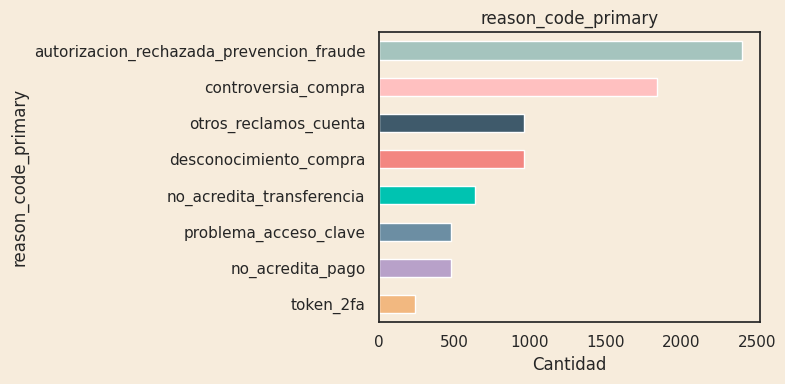

In [172]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=labels["reason_code_primary"].value_counts(),
    ax=ax,
    title="reason_code_primary",
    xlabel="Cantidad",
    palette=cfg.palette
)

plt.tight_layout()
plt.show()

### Intenciones

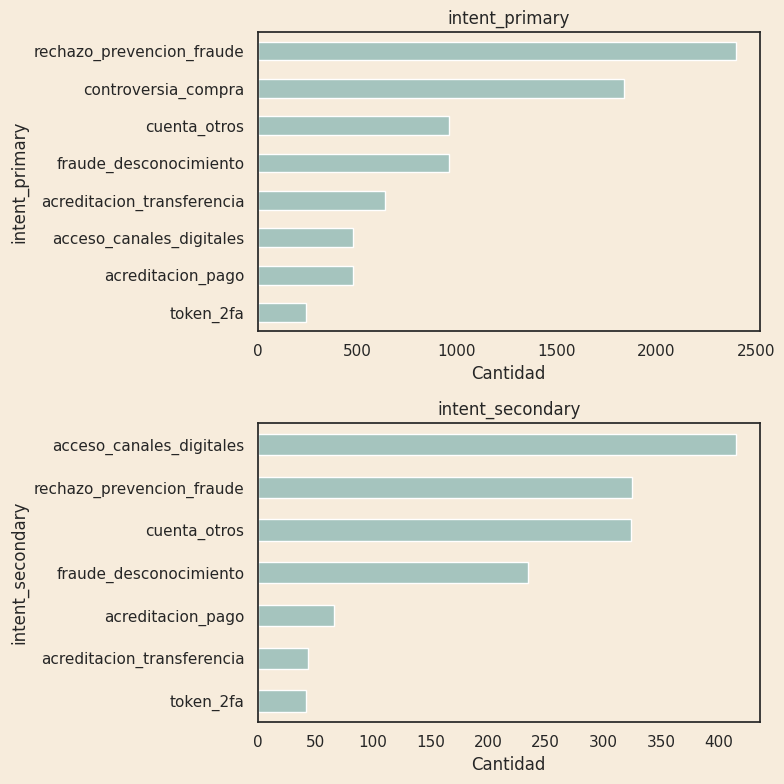

In [173]:
# Construir mapa de colores compartido por categoria
all_intents = list(set(
    labels["intent_primary"].dropna().unique().tolist() +
    labels["intent_secondary"].dropna().unique().tolist()
))

palette_map = {
    intent: color
    for intent, color in zip(all_intents, sns.color_palette(cfg.palette, len(all_intents)))
}

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

plot_barh(
    series=labels["intent_primary"].value_counts(),
    ax=axes[0],
    title="intent_primary",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette[0],
    # color_map=palette_map
)

if check_col(labels, "intent_secondary"):
    plot_barh(
        series=labels["intent_secondary"].value_counts(),
        ax=axes[1],
        title="intent_secondary",
        xlabel="Cantidad",
        color = cfg.palette[0],
        # palette=cfg.palette[0],
        # color_map=palette_map
    )

plt.tight_layout()
plt.show()


**Intent primario:** La clase dominante es rechazo_prevencion_fraude, seguida
por controversia_compra. La clase con menor representación es token_2fa.
El balance entre clases es razonable aunque no perfecto, lo que es esperable
en datasets sintéticos diseñados para reflejar distribuciones realistas de
reclamos bancarios. intent_secondary está disponible para menos del 20% de
los casos y no se utilizará para entrenamiento.

**Producto y canal:** Las tarjetas (crédito y débito) concentran más de la
mitad de los casos, lo que refleja el peso de estos productos en la operativa
bancaria. El canal chat es ampliamente dominante, seguido por callcenter
y app. Esta distribución es consistente con la realidad de los bancos
uruguayos donde el chat ha desplazado al teléfono como canal principal.

**Severidad y fraude:** La distribución de severidad está sesgada hacia
valores bajos y medios, con pocos casos de severidad alta. El riesgo de
fraude sigue un patrón similar, con predominio de low. Esto es coherente
con la distribución esperable de reclamos bancarios donde los casos críticos
son minoría.

**Outcome y routing:** El outcome más frecuente es resolved, seguido por
claim_opened y escalated. El equipo cards_ops concentra más de la mitad del
ruteo, coherente con la dominancia de productos tipo tarjeta en el dataset.


### Producto

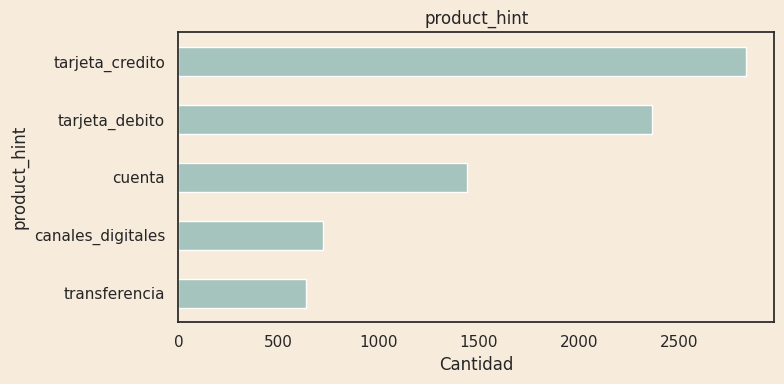

In [174]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=conversations["product_hint"].value_counts(),
    ax=ax,
    title="product_hint",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette
)

plt.tight_layout()
plt.show()

#### Consistencia: product_hint vs product_final

product_hint (tabla conversations) es el producto reportado al inicio del contacto.
product_final (tabla labels) es el producto determinado tras la clasificación.
Si divergen frecuentemente, indica ambigüedad en la asignación de productos.


In [175]:
prod_check = conversations[["conversation_id", "product_hint"]].merge(
    labels[["conversation_id", "product_final"]],
    on="conversation_id"
)

prod_check["match"] = prod_check["product_hint"] == prod_check["product_final"]
match_rate = prod_check["match"].mean() * 100

print(f"Coincidencia product_hint vs product_final: {match_rate:.1f}%")
print(f"Discrepancias: {(~prod_check['match']).sum()} de {len(prod_check)}")

if match_rate < 100:
    ct_prod = pd.crosstab(
        prod_check["product_hint"],
        prod_check["product_final"]
    )

    fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h * 1.5))
    plot_heatmap(ct_prod, ax, "product_hint vs product_final", fmt="d", cmap="YlOrRd")
    plt.tight_layout()
    plt.show()
else:
    print("Ambas columnas son idénticas en todas las conversaciones.")

Coincidencia product_hint vs product_final: 100.0%
Discrepancias: 0 de 8000
Ambas columnas son idénticas en todas las conversaciones.


### Canal

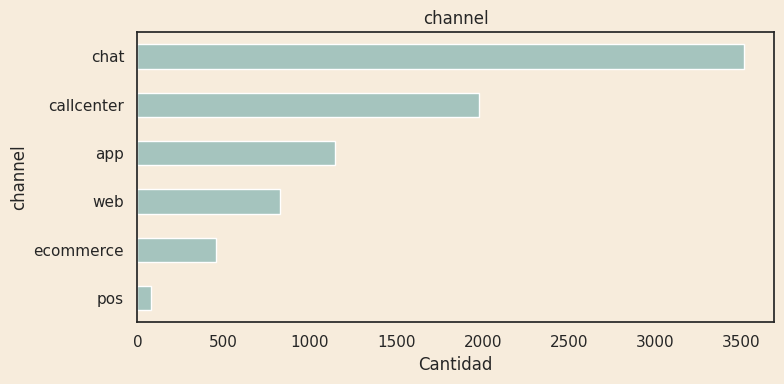

In [176]:
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))

plot_barh(
    series=conversations["channel"].value_counts(),
    ax=ax,
    title="channel",
    xlabel="Cantidad",
    color = cfg.palette[0],
    # palette=cfg.palette
)

plt.tight_layout()
plt.show()

### Categoria por labels

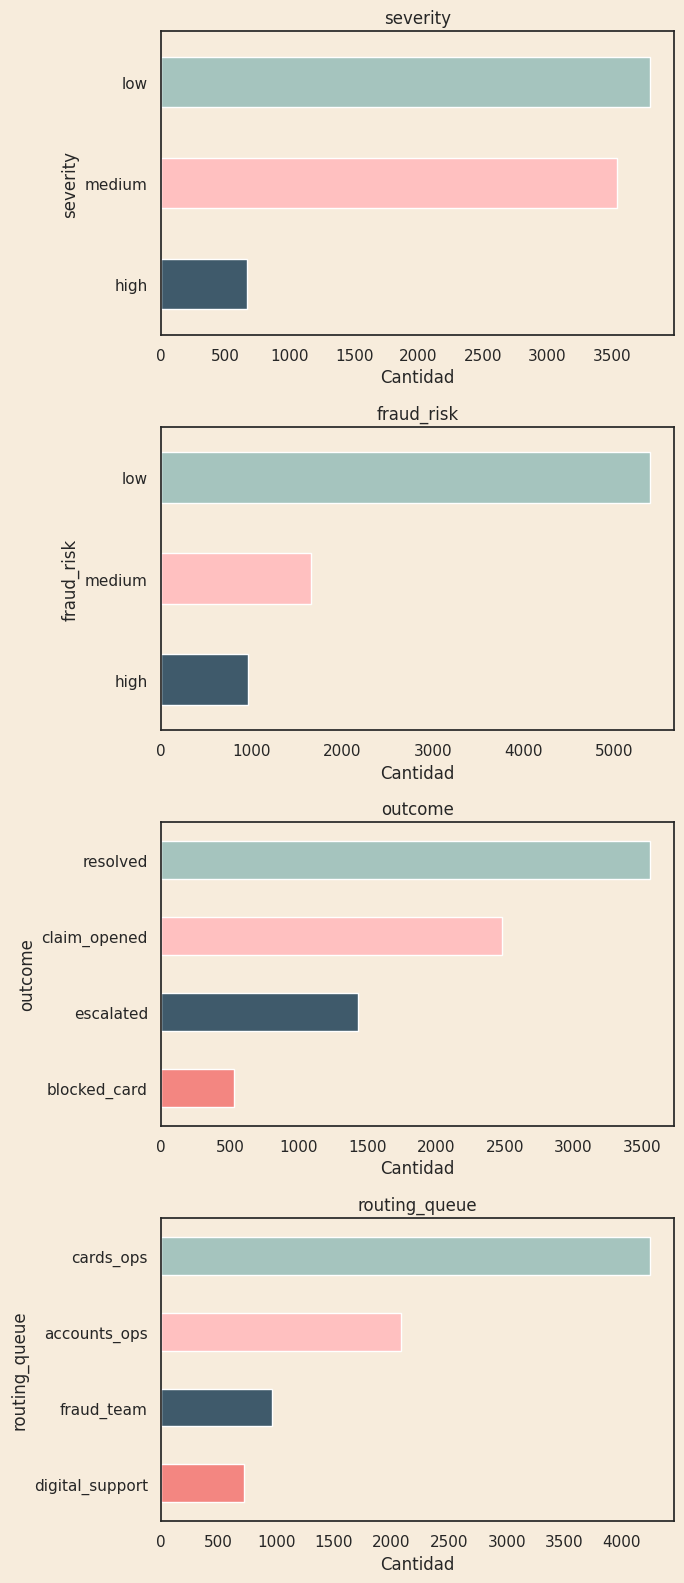

In [177]:
cat_cols = [
    c for c in ["severity", "fraud_risk", "outcome", "routing_queue"]
    if check_col(labels, c)
]

if cat_cols:
    fig, axes = plt.subplots(
        len(cat_cols),
        1,
        figsize=(7, 4 * len(cat_cols))
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cat_cols):
        plot_barh(
            series=labels[col].value_counts(),
            ax=ax,
            title=col,
            xlabel="Cantidad",
            palette=cfg.palette
        )

    plt.tight_layout()
    plt.show()

**Intents**

El intent primario muestra una distribución desbalanceada. rechazo_prevencion_fraude domina claramente con aproximadamente 2,400 casos, seguido por controversia_compra con cerca de 1,800. Los intents restantes como cuenta_otros, fraude_desconocimiento, acreditacion_transferencia, acceso_canales_digitales y acreditacion_pago tienen volúmenes similares entre sí rondando los 400 a 1,000 casos, mientras que token_2fa es el menos frecuente con aproximadamente 250 casos.
El intent secundario, disponible solo para el 18.2% de las conversaciones, muestra una distribución diferente donde acceso_canales_digitales lidera con ~415 casos. Esto sugiere que cuando existe un intent secundario, frecuentemente está relacionado con problemas de acceso digital como consecuencia del problema principal.
El desbalance en intent primario es relevante para el entrenamiento ya que el modelo podría tender a predecir las clases mayoritarias. Se evalua el uso de pesos por clase o técnicas de balanceo.

**Reason Code**

La distribución de reason_code_primary es prácticamente un espejo del intent primario, lo cual es esperable ya que ambos describen el motivo de contacto desde distintas perspectivas. autorizacion_rechazada_prevencion_fraude lidera con ~2,400 casos y controversia_compra con ~1,800, confirmando que los problemas de fraude y disputas de compra son el núcleo del dataset.

**Producto**

El 57% de las conversaciones involucran tarjetas (crédito 2,800 y débito 2,350), lo que es consistente con el predominio de intents relacionados a fraude y rechazos. Las cuentas representan 1,450 casos, seguidas por canales digitales (750) y transferencias (650). El dataset está claramente orientado a productos de tarjetas bancarias.

**Canal**

El canal chat es ampliamente dominante con 3,500 conversaciones (43.9%), seguido por callcenter (2,000) y app (1,150). Los canales web, ecommerce y pos tienen menor representación. Esto indica que el modelo estará más expuesto a patrones de texto propios de conversaciones escritas por chat, lo que podría afectar el rendimiento en canales con patrones distintos como pos.

**Severidad, Fraude, Outcome y Routing**

La severidad está concentrada en niveles low y medium (3,700 cada uno) siendo high significativamente menor (600). El riesgo de fraude sigue un patrón similar con predominio de low (5,200), lo que es coherente con un dataset donde la mayoría de los casos son rechazos preventivos y no fraudes confirmados.

En cuanto al outcome, resolved lidera con 3,550 casos, seguido de claim_opened (2,500), escalated (1,400) y blocked_card (600). Esto refleja que la mayoría de los casos se resuelven en el primer contacto pero una porción considerable requiere apertura de reclamo formal.


La cola de ruteo cards_ops concentra más del 50% de los casos (4,200), seguida por accounts_ops (1,700), fraud_team (800) y digital_support (650), distribución perfectamente alineada con el predominio de productos de tarjetas en el dataset.

**Nota:** Este resultado corresponde al split ORIGINAL del dataset y evidencia
un nivel elevado de data leakage a nivel de mensajes individuales. En la siguiente
sección se aplica un re-split basado en unicidad que reduce significativamente
este solapamiento, priorizando las conversaciones con textos más únicos para
los conjuntos de validación y test.

A nivel de conversaciones completas (texto concatenado) no se detectan duplicados
exactos entre splits, lo cual indica que el leakage se produce por reutilización
de frases individuales (saludos, respuestas tipo) y no por conversaciones copiadas.


### Longitud de mensajes

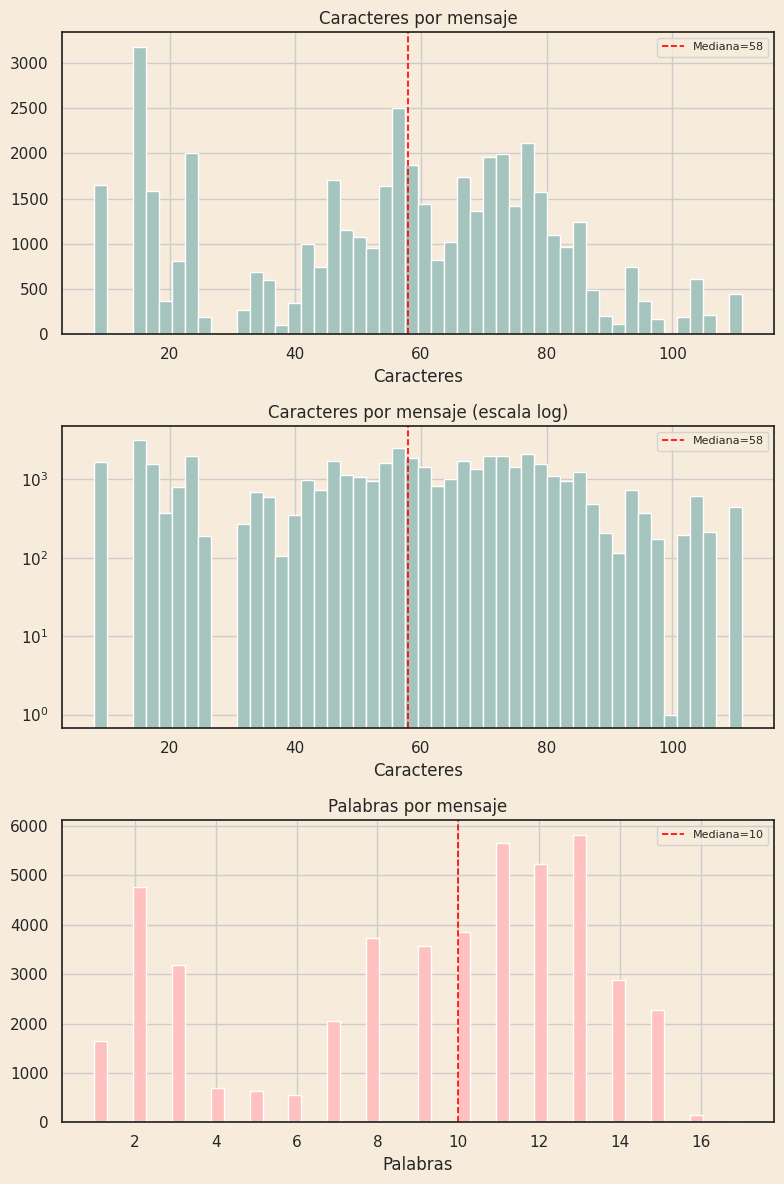



       text_len_chars  text_len_words
count         46713.0         46713.0
mean             55.7             9.0
std              25.1             4.2
min               8.0             1.0
25%              39.0             7.0
50%              58.0            10.0
75%              74.0            12.0
max             111.0            17.0


In [178]:
# Features
messages["text_len_chars"] = messages["text"].astype(str).str.len()
messages["text_len_words"] = messages["text"].astype(str).str.split().str.len()

# Figura
fig, axes = plt.subplots(3, 1, figsize=(cfg.fig_w, cfg.fig_h * 3))

plot_hist(messages["text_len_chars"], axes[0],
          title="Caracteres por mensaje",
          xlabel="Caracteres",
          bins=50,
          color=cfg.palette[0])

plot_hist(messages["text_len_chars"], axes[1],
          title="Caracteres por mensaje (escala log)",
          xlabel="Caracteres",
          bins=50,
          log=True,
          color=cfg.palette[0])

plot_hist(messages["text_len_words"], axes[2],
          title="Palabras por mensaje",
          xlabel="Palabras",
          bins=50,
          color=cfg.palette[1])

plt.tight_layout()
plt.show()

# Estadísticos
print("\n")
print(messages[["text_len_chars", "text_len_words"]]
      .describe()
      .round(1))

La distribución de longitud en caracteres y palabras es bimodal, con un
primer pico correspondiente a mensajes cortos (saludos, confirmaciones,
respuestas de una palabra) y un segundo pico correspondiente a mensajes de
contenido (descripción del problema, respuesta del agente).

Esta bimodalidad es característica de conversaciones de soporte: el cliente
alterna entre frases cortas de turno conversacional y frases largas de
descripción del reclamo.

**Estimación de tokens para BERT:** Considerando la longitud mediana de
mensajes y el promedio de mensajes por conversación, una conversación típica
genera aproximadamente 87 tokens al concatenarse con separadores [SEP]. Los
casos extremos alcanzan alrededor de 140 tokens. Un max_length de 256 tokens
es más que suficiente para cubrir la totalidad del dataset sin truncamiento
significativo.

### Timestamp offset

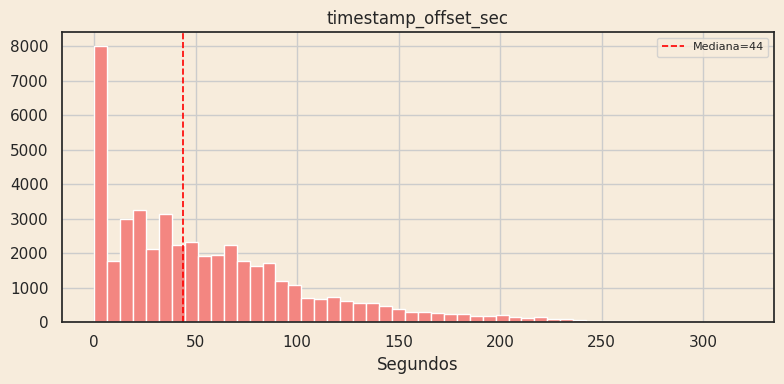

In [179]:
fig, ax = plt.subplots(1, figsize=(cfg.fig_w, cfg.fig_h))

plot_hist(
    series=messages["timestamp_offset_sec"],
    ax=ax,
    title="timestamp_offset_sec",
    xlabel="Segundos",
    bins=50,
    color=cfg.palette[3]
)

plt.tight_layout()
plt.show()

### Longitud y duracion por intencion

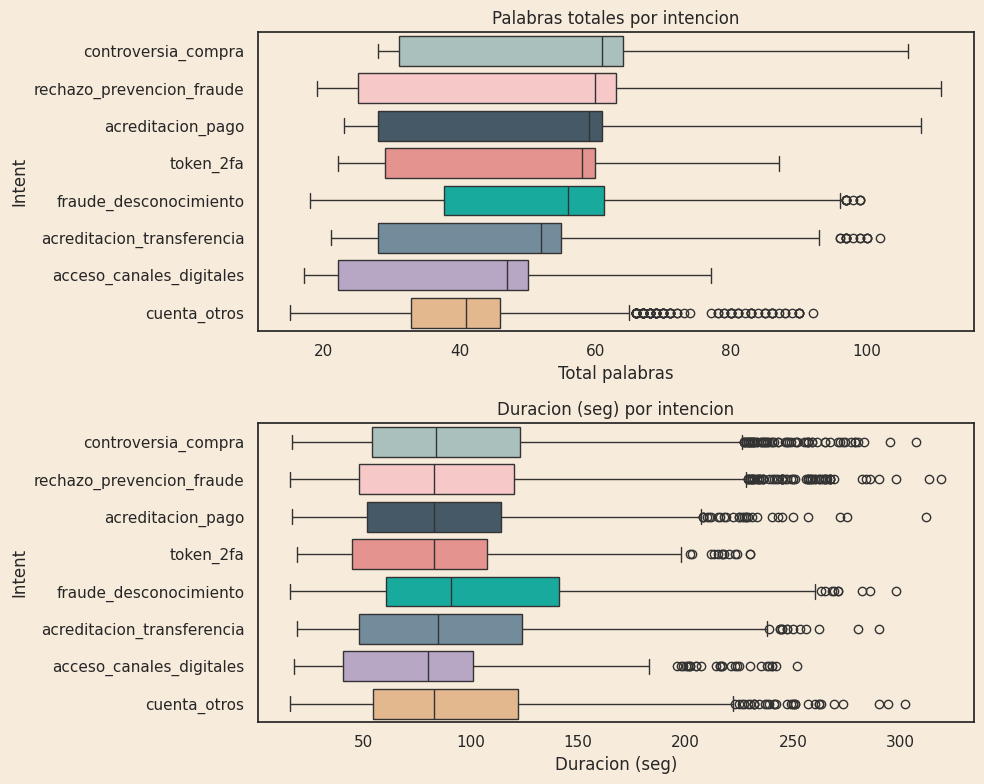

In [180]:
order_intent = (
    conv_stats
    .groupby("intent_primary")["total_words"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Palabras totales por intención
sns.boxplot(
    data=conv_stats,
    x="total_words",
    y="intent_primary",
    order=order_intent,
    ax=axes[0],
    palette=cfg.palette
)

axes[0].set_title("Palabras totales por intencion")
axes[0].set_xlabel("Total palabras")
axes[0].set_ylabel("Intent")

# Duración en segundos por intención
sns.boxplot(
    data=conv_stats,
    x="duracion_sec",
    y="intent_primary",
    order=order_intent,
    ax=axes[1],
    palette=cfg.palette
)

axes[1].set_title("Duracion (seg) por intencion")
axes[1].set_xlabel("Duracion (seg)")
axes[1].set_ylabel("Intent")

plt.tight_layout()
plt.show()

**Caracteres por mensaje**

La distribución es bimodal, con dos picos claramente visibles: uno alrededor de los 25 caracteres y otro alrededor de los 60-75 caracteres. Esto sugiere que hay dos tipos de mensajes bien diferenciados: mensajes cortos (saludos, confirmaciones, respuestas breves como "Gracias.", "Entendido.", "Sí") y mensajes más largos donde el cliente o agente describe un problema o da una explicación. La mediana de 58 caracteres indica que la mitad de los mensajes son relativamente cortos.

**Caracteres por mensaje (escala log)**

La escala logarítmica confirma que no hay mensajes extremadamente largos o atípicos que distorsionen la distribución. La distribución es bastante uniforme en escala log, lo que indica que no hay outliers severos y que el rango de longitudes es razonablemente acotado, lo cual es positivo para el entrenamiento ya que el modelo no tendrá que lidiar con textos extremadamente largos.

**Palabras por mensaje**

La distribución también es bimodal con un patrón similar. Hay un pico importante en mensajes de 2-3 palabras y otro pico en mensajes de 11-13 palabras. La mediana de 10 palabras es consistente con la mediana de 58 caracteres (aproximadamente 5-6 caracteres por palabra en español). La caída abrupta después de las 14 palabras indica que los mensajes raramente superan esa longitud.

**Duración de las conversaciones**

La distribución del timestamp muestra una cola larga hacia la derecha con mediana de 44 segundos, indicando que la mayoría de los mensajes ocurren en el primer minuto de conversación. El pico pronunciado en el primer bin corresponde a los mensajes iniciales de cada conversación que siempre tienen timestamp 0. Con un máximo de 319 segundos (~5 minutos), se confirma que las conversaciones son breves y transaccionales, lo cual es consistente con el perfil de mensajes cortos y concisos observado en el análisis anterior.

**Conclusión general**

La distribución es bimodal, con un primer pico alrededor de los 25 caracteres correspondiente a mensajes cortos transaccionales, y un segundo pico alrededor de los 70 caracteres para mensajes más descriptivos. La ausencia de mensajes extremadamente largos indica que el costo de fine-tuning será relativamente bajo dado que la mayoría de las secuencias son cortas y el max_length de 256 tokens es más que suficiente.

Nota: considerando que el modelo procesa tokens y no caracteres, y que en español la relación aproximada es de 1 a 2 tokens por palabra, una conversación típica de 5.8 mensajes con mediana de 10 palabras por mensaje genera aproximadamente 87 tokens. Incluso en el caso más extremo del dataset, con mensajes de hasta 16 palabras, una conversación completa alcanza aproximadamente 140 tokens. Sumando los tokens especiales del tokenizer como [CLS], [SEP] y los separadores entre mensajes configurados, el total se mantiene holgadamente por debajo del max_length de 256 tokens configurado.

### Longitud de Conversaciones Completas

El modelo procesará conversaciones enteras (todos los mensajes concatenados),
no mensajes individuales. Estas estadísticas reflejan el input real del modelo.

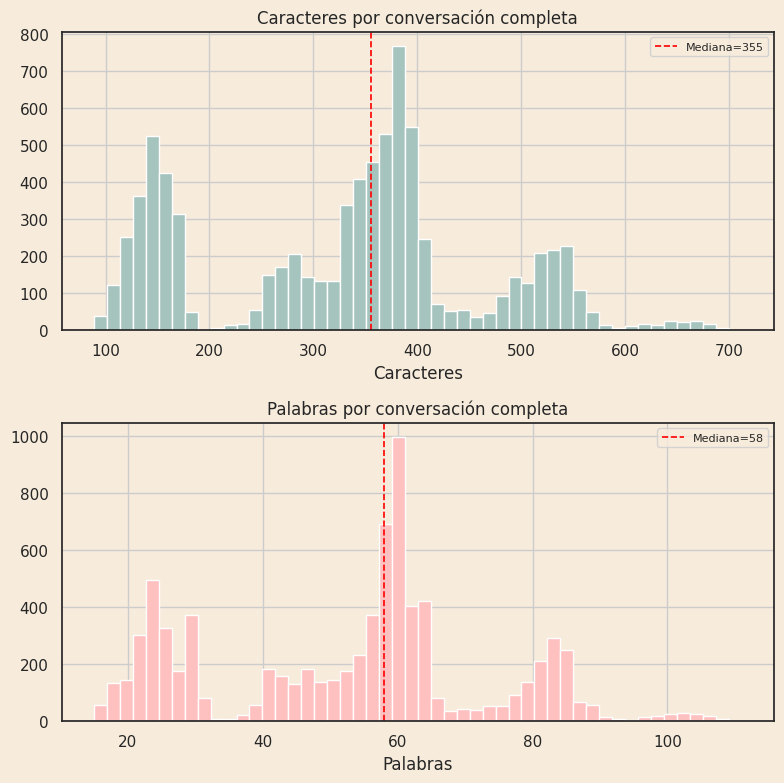


Estadísticas de conversaciones completas:
       total_chars  total_words  n_msgs
count       8000.0       8000.0  8000.0
mean         330.4         52.8     5.8
std          135.6         20.9     2.1
min           89.0         15.0     3.0
25%          173.0         30.0     3.0
50%          355.0         58.0     6.0
75%          396.0         62.0     6.0
max          712.0        111.0    11.0
  P90: 523 chars, 83 palabras
  P95: 545 chars, 85 palabras
  P99: 645 chars, 101 palabras


In [181]:
conv_full = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .agg(
        full_text=lambda x: " ".join(x.astype(str)),
        n_msgs="count"
    )
    .reset_index()
)
conv_full["total_chars"] = conv_full["full_text"].str.len()
conv_full["total_words"] = conv_full["full_text"].str.split().str.len()

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

plot_hist(conv_full["total_chars"], axes[0],
          title="Caracteres por conversación completa",
          xlabel="Caracteres", bins=50, color=cfg.palette[0])

plot_hist(conv_full["total_words"], axes[1],
          title="Palabras por conversación completa",
          xlabel="Palabras", bins=50, color=cfg.palette[1])

plt.tight_layout()
plt.show()

print("\nEstadísticas de conversaciones completas:")
print(conv_full[["total_chars", "total_words", "n_msgs"]].describe().round(1))

# Percentiles clave para dimensionar max_length
for p in [90, 95, 99]:
    chars_p = conv_full["total_chars"].quantile(p / 100)
    words_p = conv_full["total_words"].quantile(p / 100)
    print(f"  P{p}: {chars_p:.0f} chars, {words_p:.0f} palabras")

### Análisis de longitud en tokens reales


La estimación de tokens basada en palabras es imprecisa. El tokenizer real
del modelo usa subword splitting, donde palabras con tildes, compuestos y
términos bancarios pueden generar más tokens que palabras.
Se usa BETO (bert-base-spanish-wwm-cased) como referencia.

In [182]:
# !pip uninstall -y transformers
# !pip install transformers==4.41.2

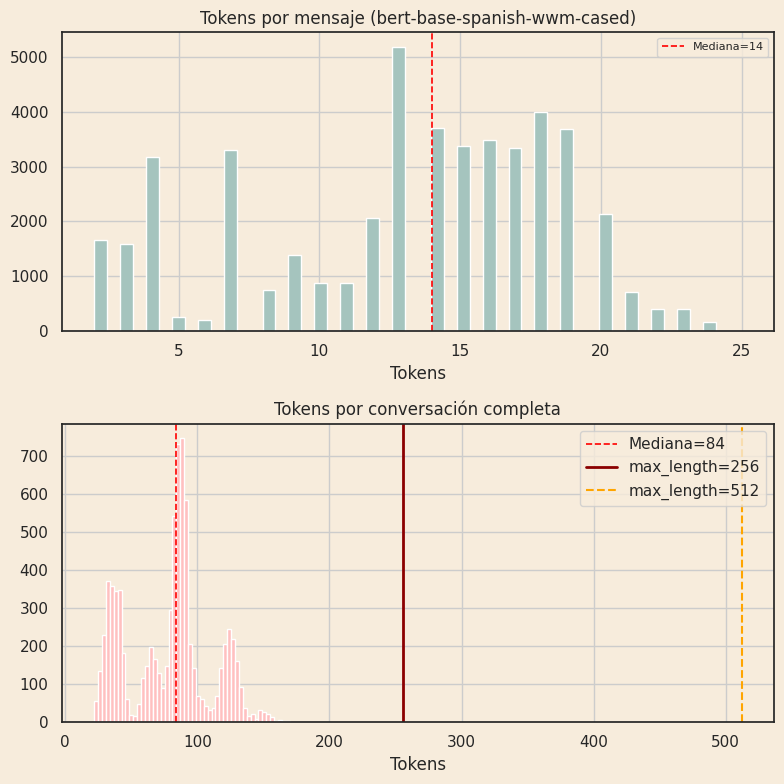


Tokenizer: dccuchile/bert-base-spanish-wwm-cased
Tokens por conversación completa:
count    8000.0
mean       78.5
std        31.6
min        22.0
25%        45.0
50%        84.0
75%        93.0
max       170.0
Name: n_tokens, dtype: float64

  Conversaciones > 256 tokens: 0.0%
  Conversaciones > 512 tokens: 0.0%

  Ratio real tokens/palabra: 1.49

 max_length=256 cubre el 100.0% de las conversaciones.


In [183]:
try:
    from transformers import AutoTokenizer

    MODEL_NAME = cfg.bert_model_name
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Tokenizar mensajes individuales
    messages["n_tokens"] = messages["text"].astype(str).apply(
        lambda x: len(tokenizer.encode(x, add_special_tokens=False))
    )

    # Tokenizar conversaciones completas (reutilizar conv_full de sección 3.7)
    conv_full["n_tokens"] = conv_full["full_text"].apply(
        lambda x: len(tokenizer.encode(x, add_special_tokens=True))
    )

    fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

    plot_hist(messages["n_tokens"], axes[0],
              title=f"Tokens por mensaje ({MODEL_NAME.split('/')[-1]})",
              xlabel="Tokens", bins=50, color=cfg.palette[0])

    plot_hist(conv_full["n_tokens"], axes[1],
              title=f"Tokens por conversación completa",
              xlabel="Tokens", bins=50, color=cfg.palette[1])

    # Línea de referencia en max_length=256
    axes[1].axvline(256, color="darkred", ls="-", lw=2, label="max_length=256")
    axes[1].axvline(512, color="orange", ls="--", lw=1.5, label="max_length=512")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Estadísticas y verificación del claim
    pct_over_256 = (conv_full["n_tokens"] > 256).mean() * 100
    pct_over_512 = (conv_full["n_tokens"] > 512).mean() * 100

    print(f"\nTokenizer: {MODEL_NAME}")
    print(f"Tokens por conversación completa:")
    print(conv_full["n_tokens"].describe().round(1))
    print(f"\n  Conversaciones > 256 tokens: {pct_over_256:.1f}%")
    print(f"  Conversaciones > 512 tokens: {pct_over_512:.1f}%")

    # Ratio tokens/palabra real vs. estimación del EDA original
    ratio = conv_full["n_tokens"].sum() / conv_full["total_words"].sum()
    print(f"\n  Ratio real tokens/palabra: {ratio:.2f}")

    if pct_over_256 > 5:
        print(f"\n⚠ ALERTA: {pct_over_256:.1f}% de conversaciones exceden 256 tokens.")
        print("  Considerar aumentar max_length o truncar con estrategia.")
    else:
        print(f"\n max_length=256 cubre el {100-pct_over_256:.1f}% de las conversaciones.")

except ImportError:
    print("INFO: 'transformers' no instalado. Se omite análisis de tokens.")
    print("      Instalar con: pip install transformers")

### Mensajes por conversacion

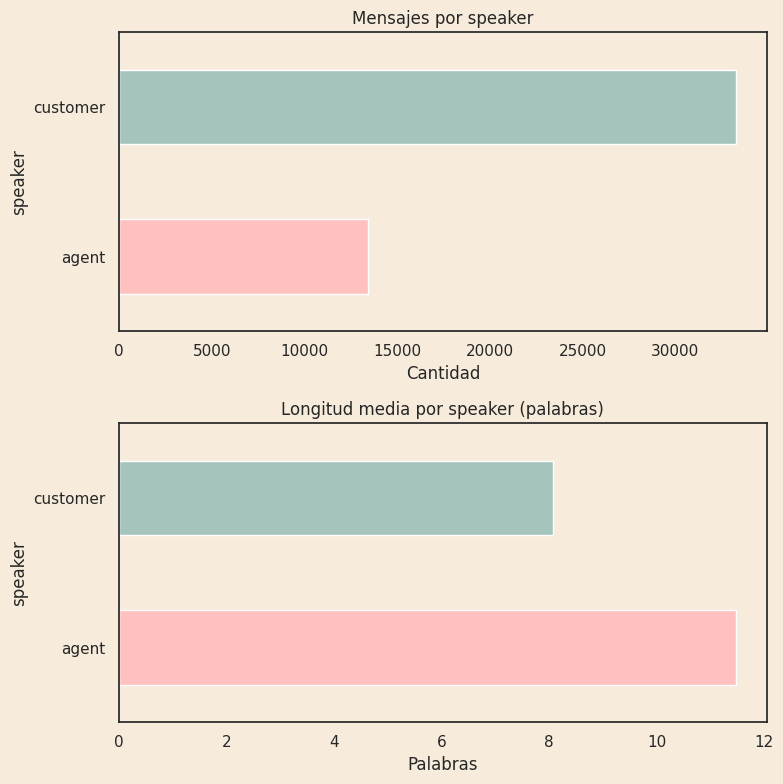

In [184]:
fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 2))

# Mensajes por speaker
plot_barh(
    series=messages["speaker"].value_counts(),
    ax=axes[0],
    title="Mensajes por speaker",
    xlabel="Cantidad",
    palette=cfg.palette
)

# Longitud media por speaker
plot_barh(
    series=messages.groupby("speaker")[
        "text_len_words"].mean().sort_values(ascending=True),
    ax=axes[1],
    title="Longitud media por speaker (palabras)",
    xlabel="Palabras",
    palette=cfg.palette
)

plt.tight_layout()
plt.show()

In [185]:
# ─── Estadísticas por speaker (dinámico) ───
_speaker_counts = messages["speaker"].value_counts()
_speaker_mean_words = messages.groupby("speaker")["text_len_words"].mean()
_cust_n = _speaker_counts.get("customer", 0)
_agent_n = _speaker_counts.get("agent", 0)
_cust_words = _speaker_mean_words.get("customer", 0)
_agent_words = _speaker_mean_words.get("agent", 0)

print(f"\nSpeaker stats:")
print(f"  customer: {_cust_n:,} intervenciones | promedio {_cust_words:.2f} palabras/msg")
print(f"  agent:    {_agent_n:,} intervenciones | promedio {_agent_words:.2f} palabras/msg")

print("""Se observa que la mayoría de los turnos corresponden al cliente. En términos
de longitud promedio, los mensajes del agente son más extensos que los del cliente,
lo que sugiere que el cliente tiende a formular reclamos de manera más breve y
directa, mientras que el agente produce respuestas relativamente más desarrolladas.""")


Speaker stats:
  customer: 33,282 intervenciones | promedio 8.07 palabras/msg
  agent:    13,431 intervenciones | promedio 11.47 palabras/msg
Se observa que la mayoría de los turnos corresponden al cliente. En términos
de longitud promedio, los mensajes del agente son más extensos que los del cliente,
lo que sugiere que el cliente tiende a formular reclamos de manera más breve y
directa, mientras que el agente produce respuestas relativamente más desarrolladas.


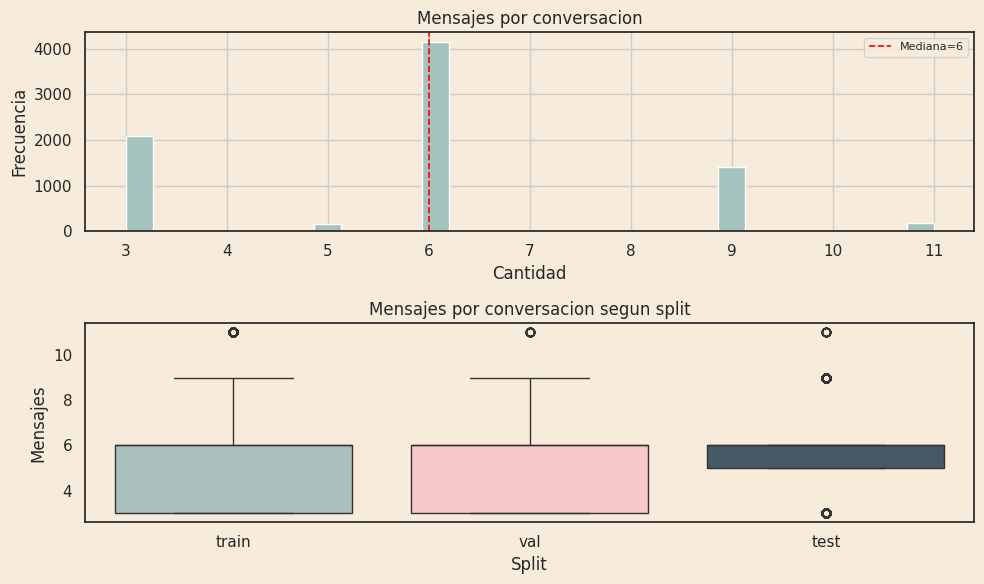

In [186]:
msgs_per_conv = (
    messages
    .groupby("conversation_id")
    .size()
    .reset_index(name="n_msgs")
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_hist(
    series=msgs_per_conv["n_msgs"],
    ax=axes[0],
    title="Mensajes por conversacion",
    xlabel="Cantidad",
    bins=30,
    color=cfg.palette[0]
)

axes[0].set_title("Mensajes por conversacion")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Frecuencia")

conv_split = msgs_per_conv.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

sns.boxplot(
    data=conv_split,
    x="split",
    y="n_msgs",
    order=["train", "val", "test"],
    palette=cfg.palette,
    ax=axes[1]
)

axes[1].set_title("Mensajes por conversacion segun split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Mensajes")

plt.tight_layout()
plt.show()

La distribución de mensajes por conversación muestra una mediana de 6 intervenciones, con la mayoría de las conversaciones concentradas entre 3 y 9 mensajes, lo que confirma una estructura relativamente breve y homogénea.

### Correlaciones

#### Heatmaps - Intencion vs Categorias

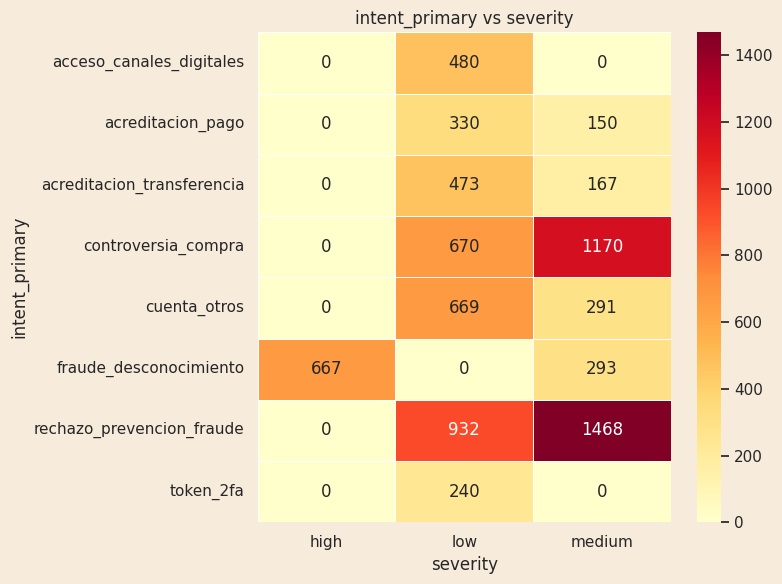

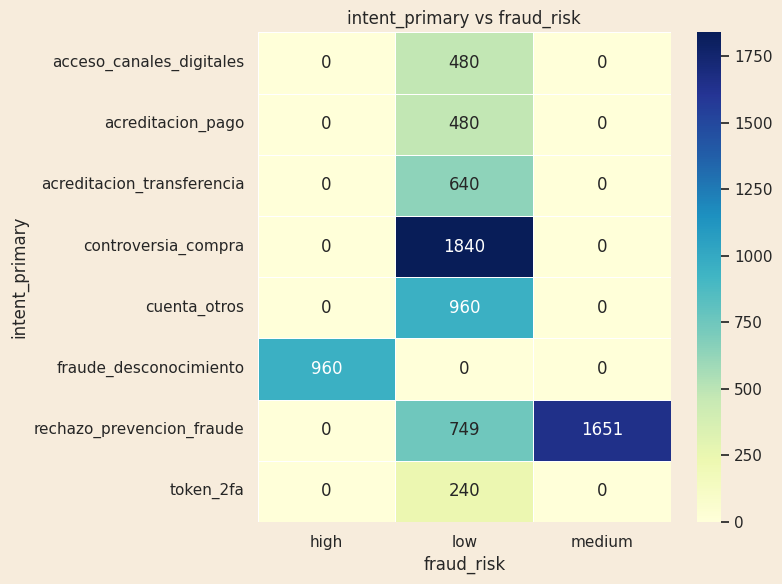

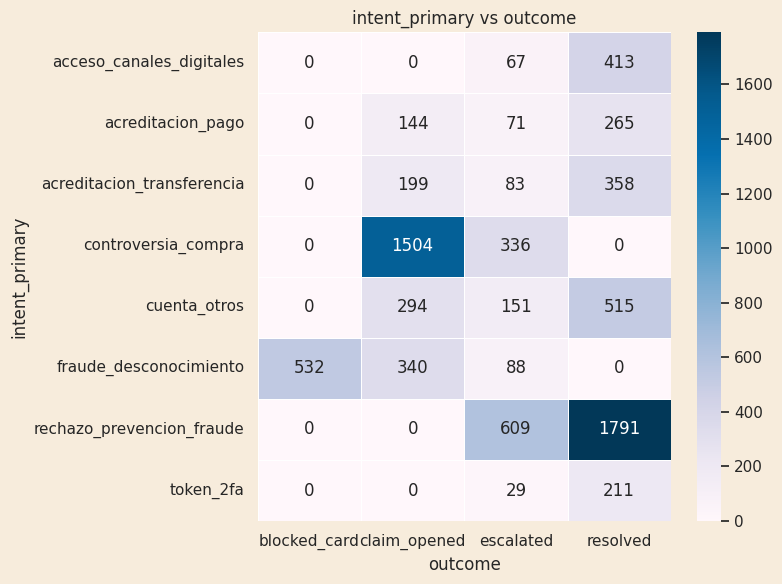

In [187]:
cruces = [
    ("severity", "YlOrRd"),
    ("fraud_risk", "YlGnBu"),
    ("outcome", "PuBu"),
]

for col, cmap in cruces:
    ct = crosstab_safe(labels, "intent_primary", col)

    if ct is not None:
        fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h * 1.5))

        plot_heatmap(
            ct=ct,
            ax=ax,
            title=f"intent_primary vs {col}",
            fmt="d",
            cmap=cmap
        )

        plt.tight_layout()
        plt.show()

**Intent × Severidad:** Los intents relacionados con fraude
(fraude_desconocimiento, rechazo_prevencion_fraude) muestran una proporción
mayor de casos de severidad alta respecto a intents transaccionales como
consulta_saldo o token_2fa. Esta asociación es semánticamente coherente
y podría ser explotada en un modelo multitask.

**Intent × Outcome:** Los intents de fraude tienden a resolverse con
escalado o apertura de reclamo formal, mientras que intents más simples
como token_2fa o acceso_canales_digitales se resuelven con mayor frecuencia
en el primer contacto. El patrón de routing es consecuente: los casos de
fraude van mayoritariamente a fraud_team, los de tarjetas a cards_ops.

Estas correlaciones confirman que las variables auxiliares (severity,
outcome, routing_queue) contienen información consistente con el intent
primario, lo que las hace candidatas útiles para regularización multitask
durante el entrenamiento.

### Entidades - Distribucion y spans

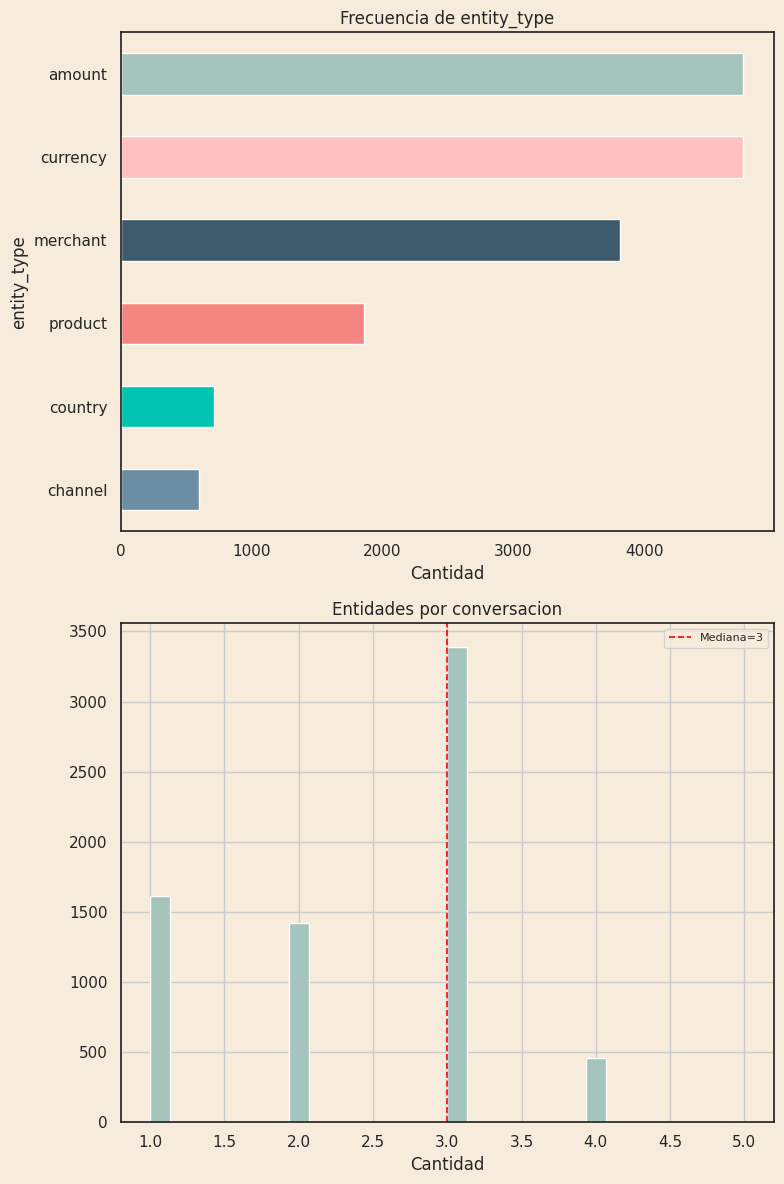

In [188]:
entities["span_len"] = (
    entities["end_char"] - entities["start_char"]
).clip(lower=0)

fig, axes = plt.subplots(2, 1, figsize=(cfg.fig_w, cfg.fig_h * 3))

plot_barh(
    series=entities["entity_type"].value_counts(),
    ax=axes[0],
    title="Frecuencia de entity_type",
    xlabel="Cantidad",
    palette=cfg.palette
)

plot_hist(
    series=entities.groupby("conversation_id").size(),
    ax=axes[1],
    title="Entidades por conversacion",
    xlabel="Cantidad",
    bins=30,
    color=cfg.palette[0]
)

plt.tight_layout()
plt.show()

Este gráfico muestra cuántas entidades tiene cada conversación. Sirve para entender la densidad de anotación del dataset. El patrón es claramente discreto con picos en 1, 2, 3 y 4 entidades por conversación, siendo 3 el valor más frecuente (~3,400 conversaciones). Esto indica que la mayoría de las conversaciones tienen entre 1 y 4 entidades, con muy pocas superando ese rango. Al igual que con los mensajes por conversación, este patrón discreto es característico de datos sintéticos generados con plantillas fijas. Para el modelo NER esto es positivo ya que las secuencias no estarán saturadas de entidades y el aprendizaje de los límites entre entidades será más claro.

#### Distribución de Confidence en Entidades

El campo confidence indica la certeza del extractor al detectar cada entidad.
Analizar su distribución permite decidir si filtrar entidades de baja confianza.

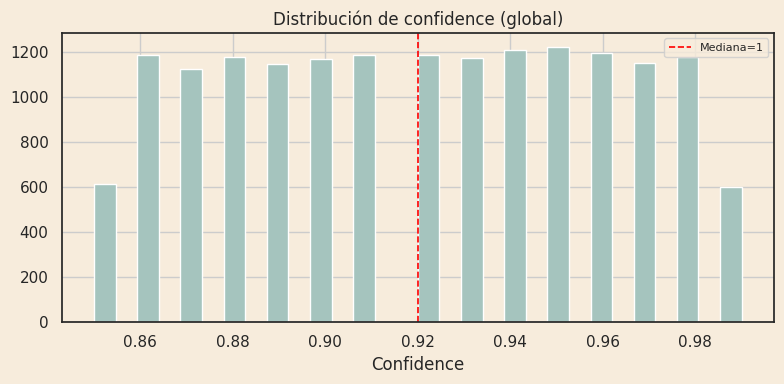

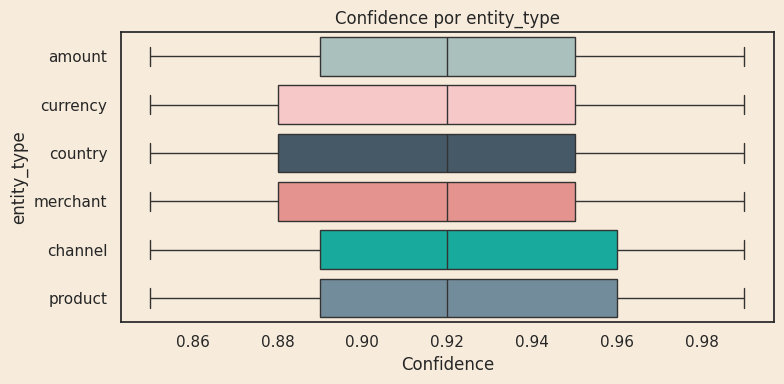


Entidades por debajo de umbrales de confianza:
  confidence < 0.95: 11,162 (67.6%)
  confidence < 0.9: 5,245 (31.8%)
  confidence < 0.85: 0 (0.0%)


In [189]:
# Histograma global de confidence
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
plot_hist(
    entities["confidence"],
    ax,
    title="Distribución de confidence (global)",
    xlabel="Confidence",
    bins=30,
    color=cfg.palette[0]
)
plt.tight_layout()
plt.show()

# Boxplot por tipo de entidad
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
sns.boxplot(
    data=entities,
    x="confidence",
    y="entity_type",
    hue="entity_type",
    palette=cfg.palette,
    ax=ax,
    legend=False
)
ax.set_title("Confidence por entity_type")
ax.set_xlabel("Confidence")
plt.tight_layout()
plt.show()

# Porcentaje bajo umbrales comunes
print("\nEntidades por debajo de umbrales de confianza:")
for threshold in [0.95, 0.90, 0.85]:
    n_below = (entities["confidence"] < threshold).sum()
    pct = n_below / len(entities) * 100
    print(f"  confidence < {threshold}: {n_below:,} ({pct:.1f}%)")

#### Validación de spans de entidades

Para entrenamiento NER, es crítico que las posiciones start_char/end_char
correspondan exactamente al text_span anotado. Spans incorrectos generarían
etiquetas BIO incoherentes y degradarían el rendimiento del modelo.

In [190]:
# Extraer substring usando las posiciones anotadas
def extract_span_safe(row):
    """Extrae text[start:end] verificando límites."""
    text = str(row["text"]) if pd.notna(row["text"]) else ""
    start = int(row["start_char"])
    end = int(row["end_char"])
    if end <= len(text) and start >= 0:
        return text[start:end]
    return None  # fuera de rango

In [191]:
# Merge entidades con el texto del mensaje fuente
ent_val = entities.merge(
    messages[["message_id", "text"]],
    on="message_id",
    how="left"
)

ent_val["extracted_span"] = ent_val.apply(extract_span_safe, axis=1)
ent_val["span_match"] = ent_val["extracted_span"] == ent_val["text_span"]

# Reportar resultados
n_total = len(ent_val)
n_oob = ent_val["extracted_span"].isna().sum()
n_match = ent_val["span_match"].sum()
n_mismatch = n_total - n_match - n_oob

print("=" * 65)
print("VALIDACIÓN DE SPANS DE ENTIDADES")
print("=" * 65)
print(f"\n  Entidades totales:           {n_total:,}")
print(f"  Spans correctos (match):     {n_match:,} ({n_match/n_total*100:.1f}%)")
print(f"  Spans incorrectos (mismatch):{n_mismatch:,} ({n_mismatch/n_total*100:.1f}%)")
print(f"  Spans fuera de rango (OOB):  {n_oob:,} ({n_oob/n_total*100:.1f}%)")

if n_mismatch > 0 or n_oob > 0:
    print("\n  Ejemplos de errores:")
    errores = ent_val[~ent_val["span_match"]].head(10)
    for _, row in errores.iterrows():
        print(f"    msg={row['message_id']} | type={row['entity_type']} "
              f"| expected='{row['text_span']}' | got='{row['extracted_span']}' "
              f"| pos=[{row['start_char']}:{row['end_char']}]")

    # Desglose por tipo de entidad
    print("\n  Errores por entity_type:")
    err_by_type = (
        ent_val[~ent_val["span_match"]]
        .groupby("entity_type").size()
        .sort_values(ascending=False)
    )
    for etype, count in err_by_type.items():
        total_type = (ent_val["entity_type"] == etype).sum()
        print(f"    {etype}: {count}/{total_type} ({count/total_type*100:.1f}%)")
else:
    print("\n Todos los spans son válidos. Dataset apto para entrenamiento NER.")

VALIDACIÓN DE SPANS DE ENTIDADES

  Entidades totales:           16,502
  Spans correctos (match):     16,502 (100.0%)
  Spans incorrectos (mismatch):0 (0.0%)
  Spans fuera de rango (OOB):  0 (0.0%)

 Todos los spans son válidos. Dataset apto para entrenamiento NER.


#### Co-ocurrencia de tipos de entidad

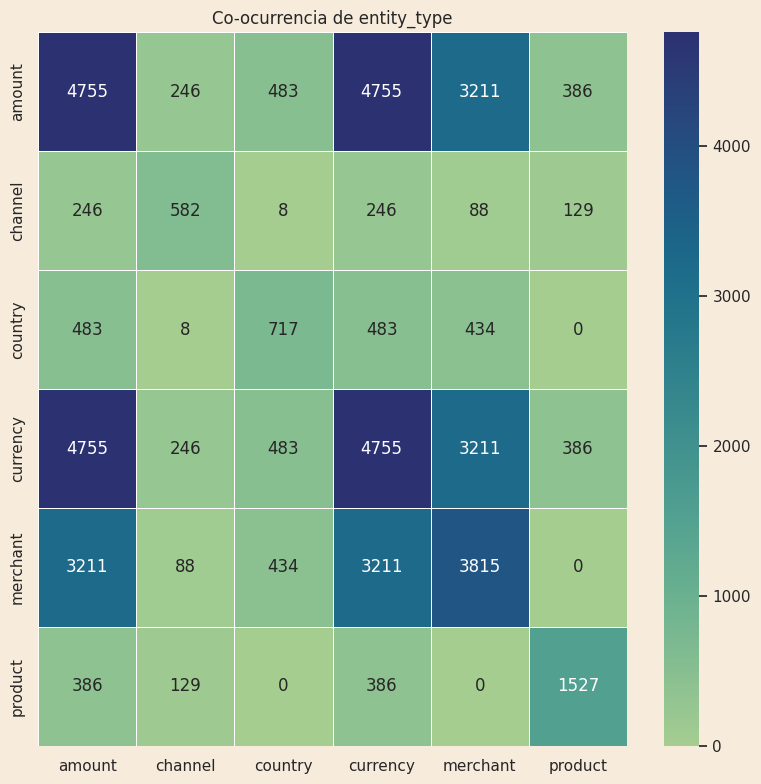

In [192]:
def coocurrencia_matrix(entities: pd.DataFrame) -> pd.DataFrame:
    """Matriz de co-ocurrencia de entity_types por conversacion."""
    all_types = sorted(entities["entity_type"].unique())
    conv_types = entities.groupby("conversation_id")["entity_type"].apply(set)
    mat = pd.DataFrame(0, index=all_types, columns=all_types)

    for ts in conv_types:
        tipos = sorted(t for t in ts if t in all_types)
        for i, t1 in enumerate(tipos):
            for t2 in tipos[i:]:
                mat.loc[t1, t2] += 1
                if t1 != t2:
                    mat.loc[t2, t1] += 1

    return mat


cooc = coocurrencia_matrix(entities)

fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_w))

plot_heatmap(
    ct=cooc,
    ax=ax,
    title="Co-ocurrencia de entity_type",
    fmt="d",
    cmap="crest"
)

plt.tight_layout()
plt.show()


La co-ocurrencia casi perfecta entre amount y currency podría hacer que el modelo aprenda a predecirlas en conjunto en lugar de identificarlas de forma independiente, lo cual es un comportamiento deseable pero que debería verificarse durante la evaluación del NER.

### Canal vs intencion

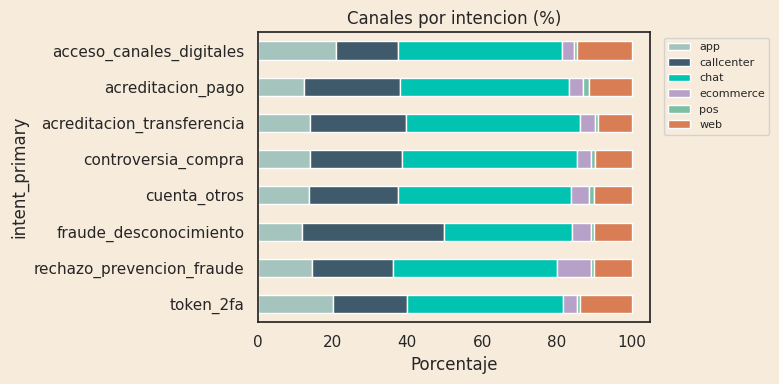

In [193]:
merged_ch = conversations[["conversation_id", "channel"]].merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

ct = crosstab_safe(merged_ch, "intent_primary", "channel")

if ct is not None:
    fig, ax = plt.subplots(1, figsize=(cfg.fig_w, cfg.fig_h))

    plot_stacked_pct(
        ct=ct,
        ax=ax,
        title="Canales por intencion (%)",
        cmap=cfg.palette
    )

    plt.tight_layout()
    plt.show()

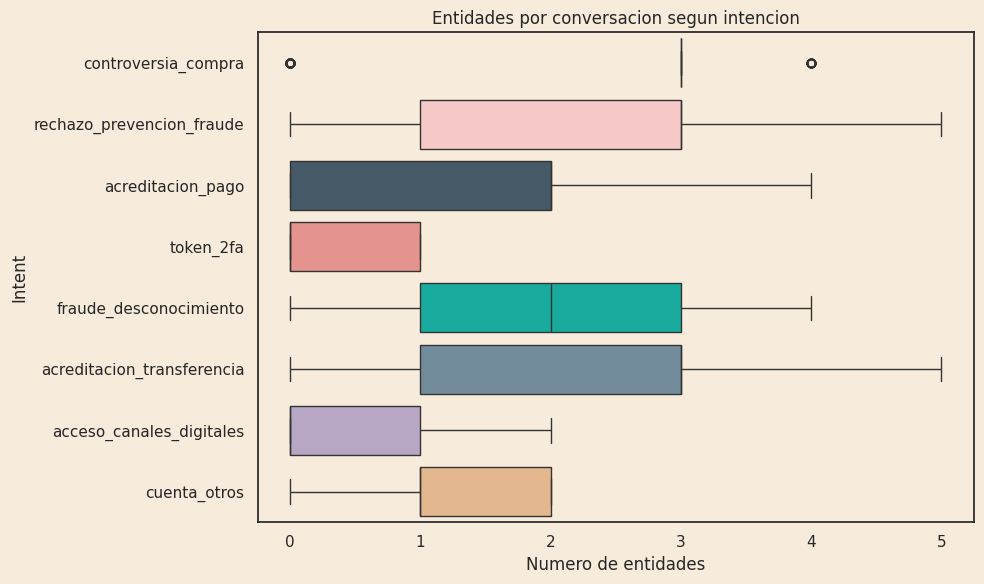

In [194]:
order_intent = conv_stats.groupby("intent_primary")["total_words"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(1, figsize=(10, 6))

sns.boxplot(
    data=conv_stats,
    x="n_entities",
    y="intent_primary",
    order=order_intent,
    palette=cfg.palette,
    ax=ax
)

ax.set_title("Entidades por conversacion segun intencion")
ax.set_xlabel("Numero de entidades")
ax.set_ylabel("Intent")

plt.tight_layout()
plt.show()

Las intenciones vinculadas a fraude_desconocimiento, acreditacion_transferencia y rechazo_prevencion_fraude presentan una mayor mediana y dispersión en la cantidad de entidades, alcanzando valores frecuentes entre 2 y 3 entidades por conversación e incluso casos extremos de hasta 4 o 5. Esto sugiere que estos reclamos requieren mayor nivel de información estructurada (montos, fechas, cuentas, transacciones, etc.), lo que incrementa la densidad de entidades.

En contraste, intenciones como token_2fa, acceso_canales_digitales y cuenta_otros tienden a concentrarse en 1 entidad por conversación y muestran menor variabilidad, lo que indica interacciones más simples desde el punto de vista informacional.

### Segmento vs Severity

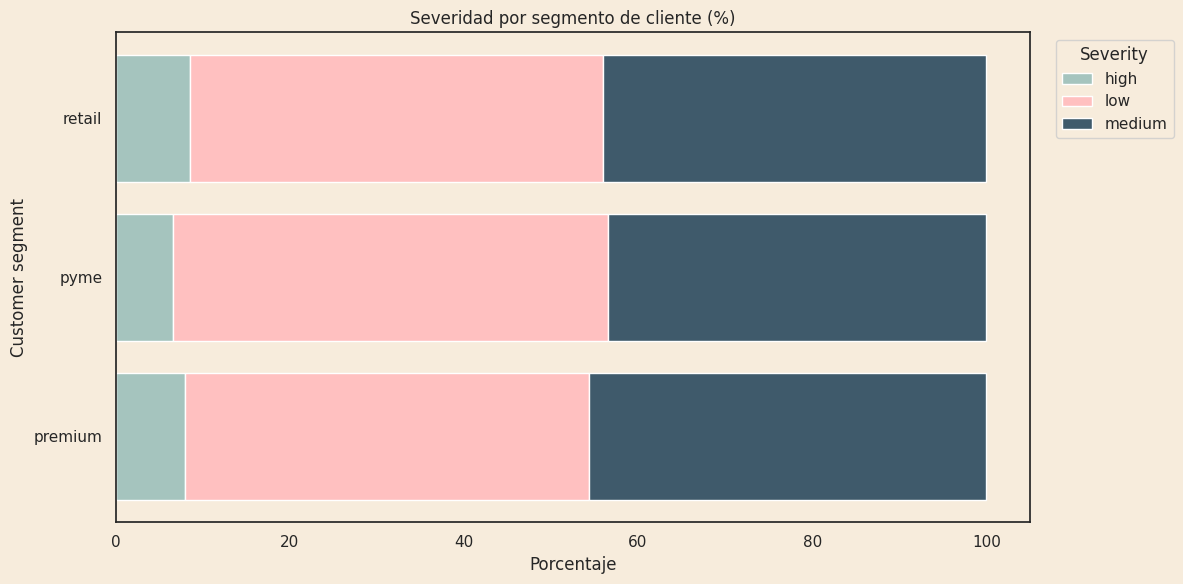

In [195]:
if check_col(conversations, "customer_segment") and check_col(labels, "severity"):

    merged_seg = conversations[["conversation_id", "customer_segment"]].merge(
        labels[["conversation_id", "severity"]],
        on="conversation_id"
    )

    ct = crosstab_safe(merged_seg, "customer_segment", "severity")

    if ct is not None:

        # Porcentaje por segmento
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

        fig, ax = plt.subplots(1, figsize=(12, 6))

        left = np.zeros(len(ct_pct.index))

        colors = sns.color_palette(cfg.palette, n_colors=len(ct_pct.columns))

        for severity, color in zip(ct_pct.columns, colors):

            ax.barh(
                ct_pct.index,
                ct_pct[severity],
                left=left,
                label=severity,
                color=color
            )

            left += ct_pct[severity].values

        ax.set_title("Severidad por segmento de cliente (%)")
        ax.set_xlabel("Porcentaje")
        ax.set_ylabel("Customer segment")

        ax.legend(
            title="Severity",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()
        plt.show()

El gráfico muestra una distribución muy similar de severidad entre los distintos segmentos de clientes (retail, pyme y premium). En los tres casos predomina la severidad low, seguida por medium, mientras que los casos high representan una proporción claramente menor. No se observan diferencias sustanciales entre segmentos.

## Balance de Intenciones por split

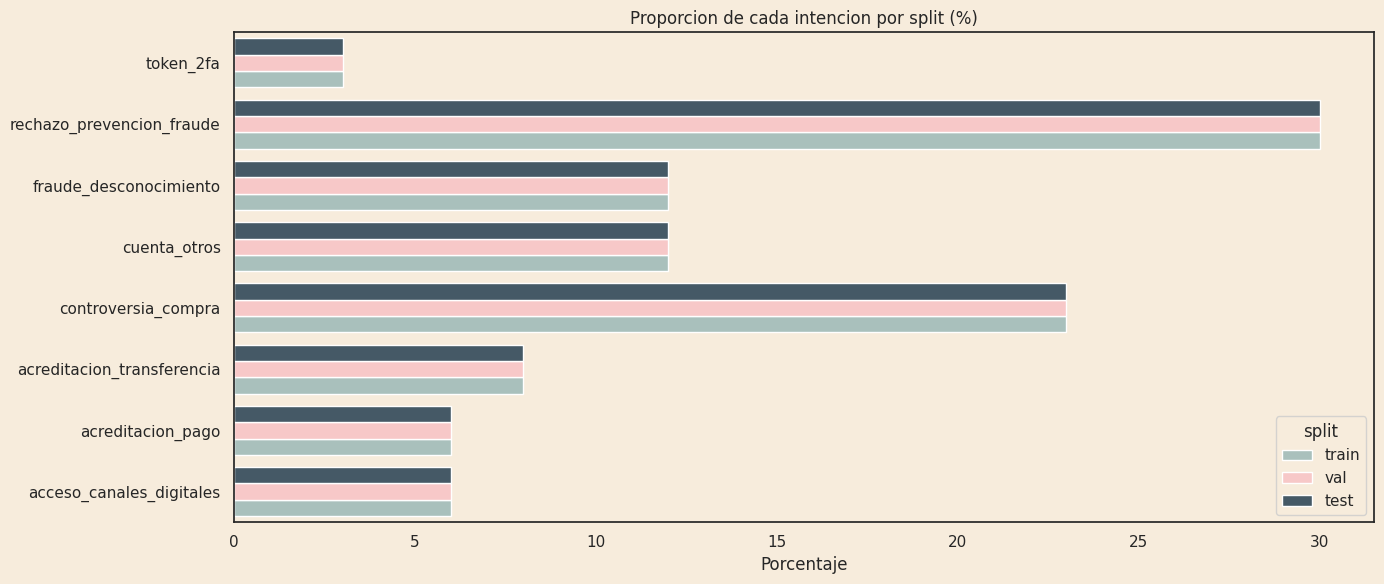

In [196]:
ct = (
    pd.crosstab(
        labels["intent_primary"],
        labels["split"],
        normalize="columns"
    ) * 100
).reset_index()

ct_long = ct.melt(
    id_vars="intent_primary",
    value_vars=["train", "val", "test"],
    var_name="split",
    value_name="pct"
)

fig, ax = plt.subplots(1, figsize=(14, 6))

sns.barplot(
    data=ct_long,
    x="pct",
    y="intent_primary",
    hue="split",
    hue_order=["train", "val", "test"],
    palette=cfg.palette,
    ax=ax
)

ax.set_title("Proporcion de cada intencion por split (%)")
ax.set_xlabel("Porcentaje")
ax.set_ylabel("")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

La proporción de cada intent_primary por split (train, val y test) muestra distribuciones prácticamente idénticas entre particiones, lo que confirma que el dataset fue dividido de manera estratificada. No se observan desviaciones relevantes en ninguna clase, incluyendo las más frecuentes como rechazo_prevencion_fraude y controversia_compra.

**Nota: esta observación corresponde al split ORIGINAL del dataset.**

La proporción de cada intent_primary por split (train, val y test) muestra
distribuciones prácticamente idénticas entre particiones en el split original,
lo que confirma que el dataset fue inicialmente dividido de manera estratificada.

Sin embargo, como se verá en la sección "Mitigación de Data Leakage", este split
se reemplaza por uno basado en unicidad de textos para reducir la filtración de
información entre particiones. El nuevo split mantiene un balance razonable de
intents (verificado con test Chi-cuadrado) pero puede presentar pequeñas
desviaciones respecto al split original debido al criterio de unicidad.

### Test Estadístico de Balance por Split (split original)

Se utiliza el test Chi-cuadrado de independencia para verificar formalmente
si la distribución de categorías es homogénea entre los splits train, val y test.
Un p-value > 0.05 indica que no hay diferencias significativas.


In [197]:
split_test_cols = ["intent_primary", "severity", "fraud_risk", "outcome", "routing_queue"]

print("=" * 65)
print("TEST CHI-CUADRADO: Homogeneidad de distribución entre splits")
print("=" * 65)

for col in split_test_cols:
    if check_col(labels, col) and check_col(labels, "split"):
        ct_test = pd.crosstab(labels[col], labels["split"])
        chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
        resultado = "Homogéneo" if p_value > 0.05 else "Diferencias significativas"
        print(f"\n  {col}:")
        print(f"    chi2 = {chi2:.4f}, p-value = {p_value:.4f}, dof = {dof}")
        print(f"    {resultado}")

TEST CHI-CUADRADO: Homogeneidad de distribución entre splits

  intent_primary:
    chi2 = 0.0000, p-value = 1.0000, dof = 14
    Homogéneo

  severity:
    chi2 = 5.7708, p-value = 0.2169, dof = 4
    Homogéneo

  fraud_risk:
    chi2 = 0.4344, p-value = 0.9796, dof = 4
    Homogéneo

  outcome:
    chi2 = 2.3500, p-value = 0.8849, dof = 6
    Homogéneo

  routing_queue:
    chi2 = 0.0000, p-value = 1.0000, dof = 6
    Homogéneo


### Data Leakage Check: Textos Compartidos entre Splits

Dado que el dataset es sintético y tiene alta reutilización de frases (3,271
textos únicos sobre 46,713 mensajes), es crítico verificar si textos idénticos
aparecen en múltiples splits. Si los mismos mensajes se repiten entre train y
test, el modelo podría memorizar frases en vez de aprender patrones generales.

In [198]:
# Cruzar mensajes con el split de su conversación
msg_split = messages.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

# Textos únicos por split
train_texts = set(msg_split[msg_split["split"] == "train"]["text"].unique())
val_texts   = set(msg_split[msg_split["split"] == "val"]["text"].unique())
test_texts  = set(msg_split[msg_split["split"] == "test"]["text"].unique())

# Overlaps
train_val  = train_texts & val_texts
train_test = train_texts & test_texts
val_test   = val_texts & test_texts

print("=" * 65)
print("DATA LEAKAGE CHECK — Textos compartidos entre splits")
print("=" * 65)
print(f"\n  Textos únicos en train: {len(train_texts)}")
print(f"  Textos únicos en val:   {len(val_texts)}")
print(f"  Textos únicos en test:  {len(test_texts)}")
print(f"\n  Overlap train ∩ val:  {len(train_val):,} textos "
      f"({len(train_val)/len(val_texts)*100:.1f}% de val)")
print(f"  Overlap train ∩ test: {len(train_test):,} textos "
      f"({len(train_test)/len(test_texts)*100:.1f}% de test)")
print(f"  Overlap val ∩ test:   {len(val_test):,} textos "
      f"({len(val_test)/len(val_texts)*100:.1f}% de val)")

# Verificar a nivel de conversación completa (texto concatenado)
conv_full_text = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " [SEP] ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_full_text = conv_full_text.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

train_convs = set(conv_full_text[conv_full_text["split"] == "train"]["full_text"])
val_convs   = set(conv_full_text[conv_full_text["split"] == "val"]["full_text"])
test_convs  = set(conv_full_text[conv_full_text["split"] == "test"]["full_text"])

print(f"\n  Conversaciones completas duplicadas train ∩ val:  {len(train_convs & val_convs)}")
print(f"  Conversaciones completas duplicadas train ∩ test: {len(train_convs & test_convs)}")
print(f"  Conversaciones completas duplicadas val ∩ test:   {len(val_convs & test_convs)}")
print("=" * 65)

if len(train_test) / len(test_texts) > 0.5:
    print("\n Más del 50% de textos de test aparecen en train, se produce data leakage.")

DATA LEAKAGE CHECK — Textos compartidos entre splits

  Textos únicos en train: 3034
  Textos únicos en val:   1220
  Textos únicos en test:  1265

  Overlap train ∩ val:  1,092 textos (89.5% de val)
  Overlap train ∩ test: 1,140 textos (90.1% de test)
  Overlap val ∩ test:   709 textos (58.1% de val)

  Conversaciones completas duplicadas train ∩ val:  6
  Conversaciones completas duplicadas train ∩ test: 7
  Conversaciones completas duplicadas val ∩ test:   0

 Más del 50% de textos de test aparecen en train, se produce data leakage.


La causa raíz es la alta reutilización de frases en el dataset sintético:
dado que existen solo ~3,271 textos únicos sobre ~46,713 mensajes, los
mismos mensajes aparecen en conversaciones de distintos splits. Sin embargo,
a nivel de conversación completa no se detectan duplicados exactos entre
splits, lo que indica que el leakage se produce por frases compartidas
(saludos, respuestas tipo) y no por conversaciones copiadas.

La sección siguiente aplica un re-split basado en unicidad que reduce
significativamente este solapamiento.

## Análisis de Separabilidad de Clases (TF-IDF + PCA/t-SNE)

Para evaluar si las features textuales permiten separar los intents,
se vectoriza el texto con TF-IDF y se proyecta en 2D con t-SNE.
Si los clusters son visualmente separables, el modelo tiene buenas
chances de aprender la clasificación.

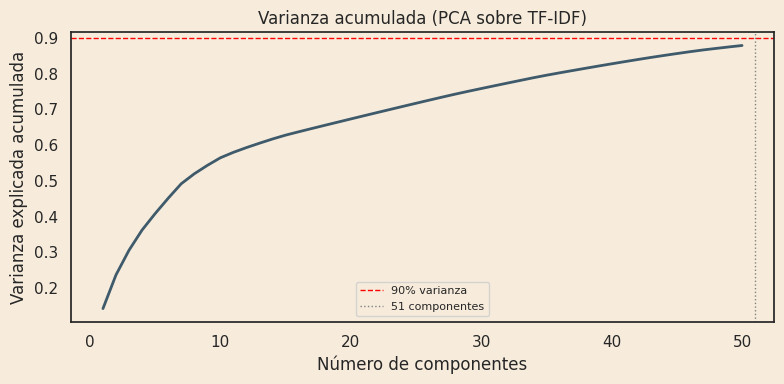


PCA: 51 componentes explican el 90% de la varianza



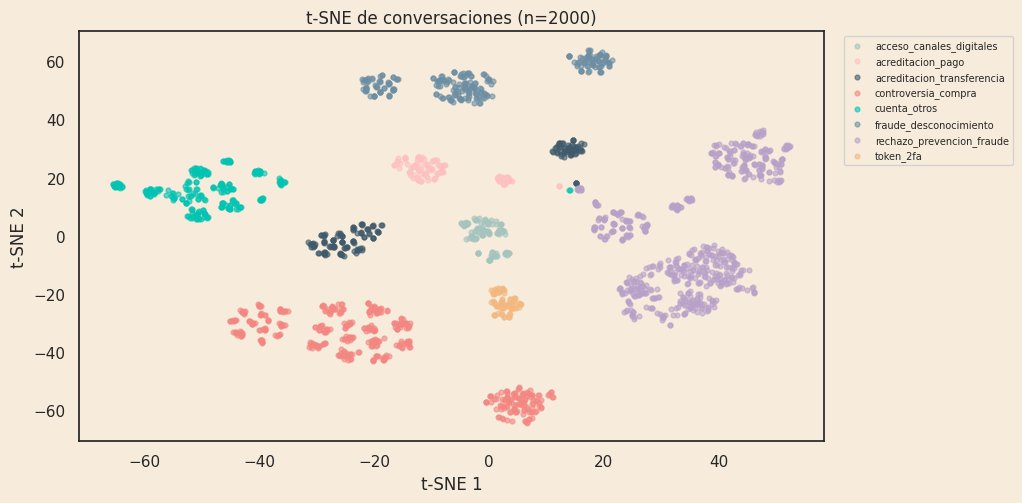

In [199]:
# Preparar texto a nivel de conversación
conv_text_sep = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_text_sep = conv_text_sep.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

# Pipeline completo
X_tsne, sample_idx, pca = compute_tsne(
    conv_text_sep["full_text"],
    n_sample=cfg.sample_pairplot,
    seed=cfg.seed
)

# PCA varianza acumulada
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.9) + 1
ax.plot(range(1, 51), cumvar, color=cfg.palette[2], linewidth=2)
ax.axhline(0.9, ls="--", color="red", lw=1, label="90% varianza")
ax.axvline(n_90, ls=":", color="gray", lw=1, label=f"{n_90} componentes")
ax.set_title("Varianza acumulada (PCA sobre TF-IDF)")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"\nPCA: {n_90} componentes explican el 90% de la varianza\n")

# t-SNE scatter
fig, ax = plt.subplots(figsize=(cfg.fig_w * 1.3, cfg.fig_h * 1.3))
plot_tsne_scatter(
    X_tsne,
    conv_text_sep["intent_primary"].iloc[sample_idx].values,
    ax, f"t-SNE de conversaciones (n={len(sample_idx)})",
    cfg.palette
)
plt.tight_layout()
plt.show()

El t-SNE muestra clusters bien definidos y claramente separados por intent,
lo que indica que las features TF-IDF capturan diferencias léxicas marcadas
entre clases. Esta alta separabilidad es un resultado esperado en un dataset
sintético donde cada intent fue generado con vocabulario relativamente
homogéneo y específico.

Sin embargo, esta separación excesiva es un indicador de fragilidad del
modelo: en lugar de aprender representaciones semánticas generalizables, el
modelo podría memorizar patrones léxicos específicos del dataset de entrenamiento
(overfitting). En producción, donde el vocabulario varía libremente, este
comportamiento resultaría en degradación de performance.

En las secciones siguientes se abordan dos mitigaciones complementarias:
1. **Re-split por unicidad:** reduce el data leakage priorizando
   conversaciones con vocabulario más diverso en val/test.
2. **Data Augmentation (EDA):** inyecta variabilidad léxica en el conjunto
   de entrenamiento para reducir la sobre-separación artificial de clusters
   y forzar al modelo a aprender features más robustas.

## Mitigación de Data Leakage y Sobre-Separación de Clusters

## Remediación: Re-split sin Data Leakage

El split original permite que textos idénticos aparezcan en train y test.
Se re-genera el split agrupando conversaciones que comparten textos INFORMATIVOS
(no genéricos como "Gracias.") para que queden en el mismo split.

Técnica: Union-Find sobre grafos de conversaciones conectadas por textos
compartidos, filtando textos que aparecen en más del 30% de las conversaciones
(son genéricos y no representan leakage real).

Con solo 3,271 textos únicos entre 8,000 conversaciones, el Union-Find conecta todo transitivamente en un solo grupo gigante. Por ende se descarta esta solución.

En vez de agrupar conversaciones, PRIORIZAR las conversaciones
con texto más único para val/test. Así, las conversaciones cuyo texto aparece en
muchas otras quedan en train (donde el leakage no importa), y las conversaciones
con texto más original van a val/test (donde el leakage sí importa).

In [200]:
# Score de unicidad por conversación
# Para cada conversación: promedio de (1 / frecuencia_del_texto) de sus mensajes
# Score alto = conversación con textos raros, Score bajo = textos muy repetidos
def unicidad_score(conv_texts):
    """Score de unicidad: promedio de 1/freq para cada texto de la conversación."""
    scores = [1.0 / text_conv_freq.get(t, 1) for t in conv_texts]
    return np.mean(scores) if scores else 0.0

Distribución de unicidad:
count    8000.0000
mean        0.0764
std         0.0690
min         0.0075
25%         0.0297
50%         0.0535
75%         0.0972
max         0.4446
Name: unicidad, dtype: float64


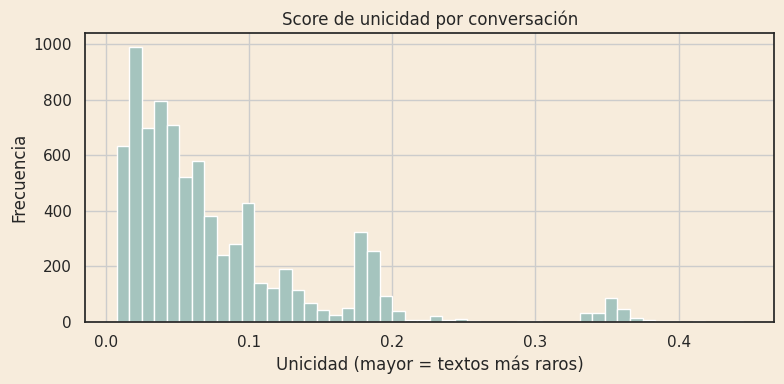


--- Nuevo split ---
split_new
train    6400
test      800
val       800
Name: count, dtype: int64

--- Verificación de leakage ---
Textos únicos en train: 2379
Textos únicos en val:   1410
Textos únicos en test:  1382
Overlap train/test: 829 textos (60.0% de test)
Overlap train/val:  1023 textos (72.6% de val)

Reducción de leakage: 90.1% → 60.0% (mejora: 30.1 puntos porcentuales)

Unicidad media por split:
split_new
test     0.2178
train    0.0520
val      0.1304
Name: unicidad, dtype: float64

--- Balance de intents por split (%) ---
split_new                   test  train   val
intent_primary                               
acceso_canales_digitales     6.0    6.0   6.0
acreditacion_pago            6.0    6.0   6.0
acreditacion_transferencia   8.0    8.0   8.0
controversia_compra         23.0   23.0  23.0
cuenta_otros                12.0   12.0  12.0
fraude_desconocimiento      12.0   12.0  12.0
rechazo_prevencion_fraude   30.0   30.0  30.0
token_2fa                    3.0    3.0   3

In [201]:
# Calcular frecuencia de cada texto en el dataset
# En cuántas conversaciones aparece cada texto?
text_conv_freq = (
    messages.drop_duplicates(subset=["conversation_id", "text"])
    .groupby("text")["conversation_id"]
    .nunique()
    .to_dict()
)

conv_unicidad = (
    messages.groupby("conversation_id")["text"]
    .apply(list)
    .reset_index(name="texts")
)
conv_unicidad["unicidad"] = conv_unicidad["texts"].apply(unicidad_score)
conv_unicidad = conv_unicidad.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

print("Distribución de unicidad:")
print(conv_unicidad["unicidad"].describe().round(4))

# Visualizar
fig, ax = plt.subplots(figsize=(cfg.fig_w, cfg.fig_h))
conv_unicidad["unicidad"].hist(bins=50, ax=ax, color=cfg.palette[0], edgecolor="white")
ax.set_title("Score de unicidad por conversación")
ax.set_xlabel("Unicidad (mayor = textos más raros)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Ordenar por unicidad y asignar splits
# Las conversaciones con mayor unicidad van primero a val/test
# Dentro de cada intent, tomar las más únicas para val/test

conv_unicidad = conv_unicidad.sort_values("unicidad", ascending=False)

new_split = {}
for intent, group in conv_unicidad.groupby("intent_primary"):
    n_total = len(group)
    n_test = max(1, int(n_total * 0.10))
    n_val = max(1, int(n_total * 0.10))

    # Las más únicas → test, luego val, el resto → train
    sorted_group = group.sort_values("unicidad", ascending=False)
    test_ids = sorted_group.iloc[:n_test]["conversation_id"].tolist()
    val_ids = sorted_group.iloc[n_test:n_test + n_val]["conversation_id"].tolist()
    train_ids = sorted_group.iloc[n_test + n_val:]["conversation_id"].tolist()

    for cid in test_ids:
        new_split[cid] = "test"
    for cid in val_ids:
        new_split[cid] = "val"
    for cid in train_ids:
        new_split[cid] = "train"

conv_unicidad["split_new"] = conv_unicidad["conversation_id"].map(new_split)

print("\n--- Nuevo split ---")
print(conv_unicidad["split_new"].value_counts())

# Verificar reducción de leakage
msg_new = messages.merge(
    conv_unicidad[["conversation_id", "split_new"]],
    on="conversation_id"
)
new_train_texts = set(msg_new[msg_new["split_new"] == "train"]["text"].unique())
new_val_texts   = set(msg_new[msg_new["split_new"] == "val"]["text"].unique())
new_test_texts  = set(msg_new[msg_new["split_new"] == "test"]["text"].unique())

overlap_train_test = new_train_texts & new_test_texts
overlap_train_val = new_train_texts & new_val_texts

print(f"\n--- Verificación de leakage ---")
print(f"Textos únicos en train: {len(new_train_texts)}")
print(f"Textos únicos en val:   {len(new_val_texts)}")
print(f"Textos únicos en test:  {len(new_test_texts)}")
print(f"Overlap train/test: {len(overlap_train_test)} textos "
      f"({len(overlap_train_test)/len(new_test_texts)*100:.1f}% de test)")
print(f"Overlap train/val:  {len(overlap_train_val)} textos "
      f"({len(overlap_train_val)/len(new_val_texts)*100:.1f}% de val)")

# Comparar con el split original
orig_overlap = len(train_texts & test_texts) / len(test_texts) * 100
new_overlap = len(overlap_train_test) / len(new_test_texts) * 100
print(f"\nReducción de leakage: {orig_overlap:.1f}% → {new_overlap:.1f}% "
      f"(mejora: {orig_overlap - new_overlap:.1f} puntos porcentuales)")

# Unicidad media por split (test/val deberían tener mayor unicidad)
print("\nUnicidad media por split:")
print(conv_unicidad.groupby("split_new")["unicidad"].mean().round(4))

# Verificar balance de intents
print("\n--- Balance de intents por split (%) ---")
ct_new = pd.crosstab(
    conv_unicidad["intent_primary"],
    conv_unicidad["split_new"],
    normalize="columns"
) * 100
print(ct_new.round(1))

# Chi-cuadrado para verificar que el balance se mantiene
ct_counts = pd.crosstab(conv_unicidad["intent_primary"], conv_unicidad["split_new"])
chi2, p_value, _, _ = stats.chi2_contingency(ct_counts)
print(f"\nChi-cuadrado: chi2={chi2:.2f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Distribución de intents homogénea entre splits.")
else:
    print("Diferencias significativas entre splits (esperado dado el sesgo por unicidad).")

In [202]:
# Actualizar split en tablas originale
split_map = conv_unicidad.set_index("conversation_id")["split_new"]
conversations["split"] = conversations["conversation_id"].map(split_map)
labels["split"] = labels["conversation_id"].map(split_map)

## Data Augmentation para Diversificar Vocabulario

Los clusters son demasiado compactos porque el dataset sintético usa vocabulario
homogéneo por clase. Se aplican 4 técnicas de augmentation (EDA: Easy Data
Augmentation, Wei & Zou 2019) para inyectar variabilidad léxica en el training
set sin cambiar la semántica del reclamo.

Técnicas:
1. Random Swap: intercambiar posición de 2 palabras
2. Random Deletion: eliminar palabras con probabilidad p
3. Random Insertion: duplicar una palabra del texto en posición aleatoria
4. Synonym Replacement: reemplazar palabras por sinónimos bancarios del español

In [203]:
# ─── Diccionario de sinónimos del dominio bancario ───
# Mapeo manual para vocabulario frecuente del dataset
SINONIMOS_BANCARIOS = {
    "tarjeta": ["plástico", "card", "medio de pago"],
    "rechazada": ["denegada", "no autorizada", "bloqueada"],
    "rechazaron": ["denegaron", "no autorizaron", "bloquearon"],
    "compra": ["transacción", "operación", "adquisición"],
    "comercio": ["establecimiento", "local", "negocio", "tienda"],
    "monto": ["importe", "valor", "suma", "cantidad"],
    "cuenta": ["cta", "producto bancario"],
    "transferencia": ["envío", "giro", "movimiento"],
    "reclamo": ["queja", "inconveniente", "problema", "incidencia"],
    "fraude": ["uso no autorizado", "operación desconocida"],
    "débito": ["extracción", "cargo"],
    "crédito": ["línea", "financiación"],
    "banco": ["entidad", "institución", "sucursal"],
    "cliente": ["usuario", "titular"],
    "pago": ["abono", "liquidación"],
    "acreditación": ["depósito", "ingreso"],
    "token": ["código", "clave dinámica", "verificador"],
    "digital": ["electrónico", "virtual", "online"],
    "bloqueo": ["suspensión", "inhabilitación"],
    "problema": ["inconveniente", "dificultad", "situación"],
}

In [204]:
def augment_synonym_replace(text: str, p_replace: float = 0.15) -> str:
    """Reemplaza palabras por sinónimos del dominio bancario."""
    words = text.split()
    new_words = []
    for w in words:
        w_lower = w.lower().rstrip(".,;:!?")
        if w_lower in SINONIMOS_BANCARIOS and random.random() < p_replace:
            sinonimo = random.choice(SINONIMOS_BANCARIOS[w_lower])
            # Preservar mayúscula si la palabra original la tenía
            if w[0].isupper():
                sinonimo = sinonimo.capitalize()
            new_words.append(sinonimo)
        else:
            new_words.append(w)
    return " ".join(new_words)


def augment_random_swap(text: str, n_swaps: int = 2) -> str:
    """Intercambia posiciones de n pares de palabras aleatorias."""
    words = text.split()
    if len(words) < 4:
        return text
    for _ in range(n_swaps):
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)


def augment_random_deletion(text: str, p_delete: float = 0.1) -> str:
    """Elimina cada palabra con probabilidad p_delete."""
    words = text.split()
    if len(words) <= 2:
        return text
    remaining = [w for w in words if random.random() > p_delete]
    return " ".join(remaining) if remaining else " ".join(words[:2])


def augment_random_insertion(text: str, p_insert: float = 0.1) -> str:
    """Duplica una palabra aleatoria del texto en posición aleatoria."""
    words = text.split()
    if len(words) < 2:
        return text
    new_words = list(words)
    n_insertions = max(1, int(len(words) * p_insert))
    for _ in range(n_insertions):
        insert_pos = random.randint(0, len(new_words))
        random_word = random.choice(words)
        new_words.insert(insert_pos, random_word)
    return " ".join(new_words)


def augment_conversation(text: str, n_augments: int = 3) -> list:
    """Genera n variantes aumentadas combinando técnicas."""
    augmenters = [
        augment_synonym_replace,
        augment_random_swap,
        augment_random_deletion,
        augment_random_insertion,
    ]
    variants = []
    for _ in range(n_augments):
        aug_text = text
        # Aplicar 1-2 técnicas en cadena para mayor variabilidad
        n_techniques = random.choice([1, 2])
        selected = random.sample(augmenters, n_techniques)
        for fn in selected:
            aug_text = fn(aug_text)
        variants.append(aug_text)
    return variants

In [205]:
# Construir texto concatenado por conversación
# (se recomputa para garantizar consistencia con el split actualizado)
conv_full_text = (
    messages.sort_values(["conversation_id", "timestamp_offset_sec"])
    .groupby("conversation_id")["text"]
    .apply(lambda x: " [SEP] ".join(x.astype(str)))
    .reset_index(name="full_text")
)
conv_full_text = conv_full_text.merge(
    conversations[["conversation_id", "split"]],
    on="conversation_id"
)

# Aplicar augmentation solo a TRAIN
train_convs_aug = conv_full_text[conv_full_text["split"] == "train"].copy()
train_convs_aug = train_convs_aug.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id"
)

print(f"Conversaciones de train: {len(train_convs_aug)}")

N_AUGMENTS = cfg.n_augments  # variantes por conversación

augmented_rows = []
for _, row in train_convs_aug.iterrows():
    variants = augment_conversation(row["full_text"], n_augments=N_AUGMENTS)
    for k, v in enumerate(variants):
        augmented_rows.append({
            "conversation_id": f"{row['conversation_id']}_aug{k}",
            "full_text": v,
            "intent_primary": row["intent_primary"],
            "split": "train",
            "is_augmented": True,
        })

df_augmented = pd.DataFrame(augmented_rows)
print(f"Variantes generadas: {len(df_augmented)}")
print(f"Total train (original + augmented): {len(train_convs_aug) + len(df_augmented)}")

# Mostrar ejemplos
print("\n--- Ejemplos de augmentation ---")
sample = train_convs_aug.iloc[0]
print(f"\nOriginal ({sample['intent_primary']}):")
print(f"  {sample['full_text'][:150]}...")

sample_variants = augment_conversation(sample["full_text"], n_augments=3)
for i, v in enumerate(sample_variants):
    print(f"\nVariante {i+1}:")
    print(f"  {v[:150]}...")

Conversaciones de train: 6400
Variantes generadas: 19200
Total train (original + augmented): 25600

--- Ejemplos de augmentation ---

Original (rechazo_prevencion_fraude):
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de débito. [SEP] Me figura autorización rechazada  por 89.00 EUR. [SEP] Bi...

Variante 1:
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de cargo [SEP] Me figura autorización denegada por 89.00 EUR. [SEP] desde ...

Variante 2:
  Hola, buenas. Soy Valentina. Estoy intentando pagar y me rechaza la tarjeta de cargo [SEP] Me figura autorización rechazada por 89.00 EUR. [SEP] Bien,...

Variante 3:
  Hola, buenas. Soy Valentina. Estoy pagar y me rechaza la tarjeta de débito. [SEP] Me figura autorización rechazada por 89.00 EUR. [SEP] Bien, reviso s...


## t-SNE antes/después


Comparar visualmente la separabilidad de clusters antes y después
de aplicar augmentation. Los clusters deberían mostrar mayor overlap
y bordes menos definidos.

Total: 25600 (6400 orig + 19200 aug)


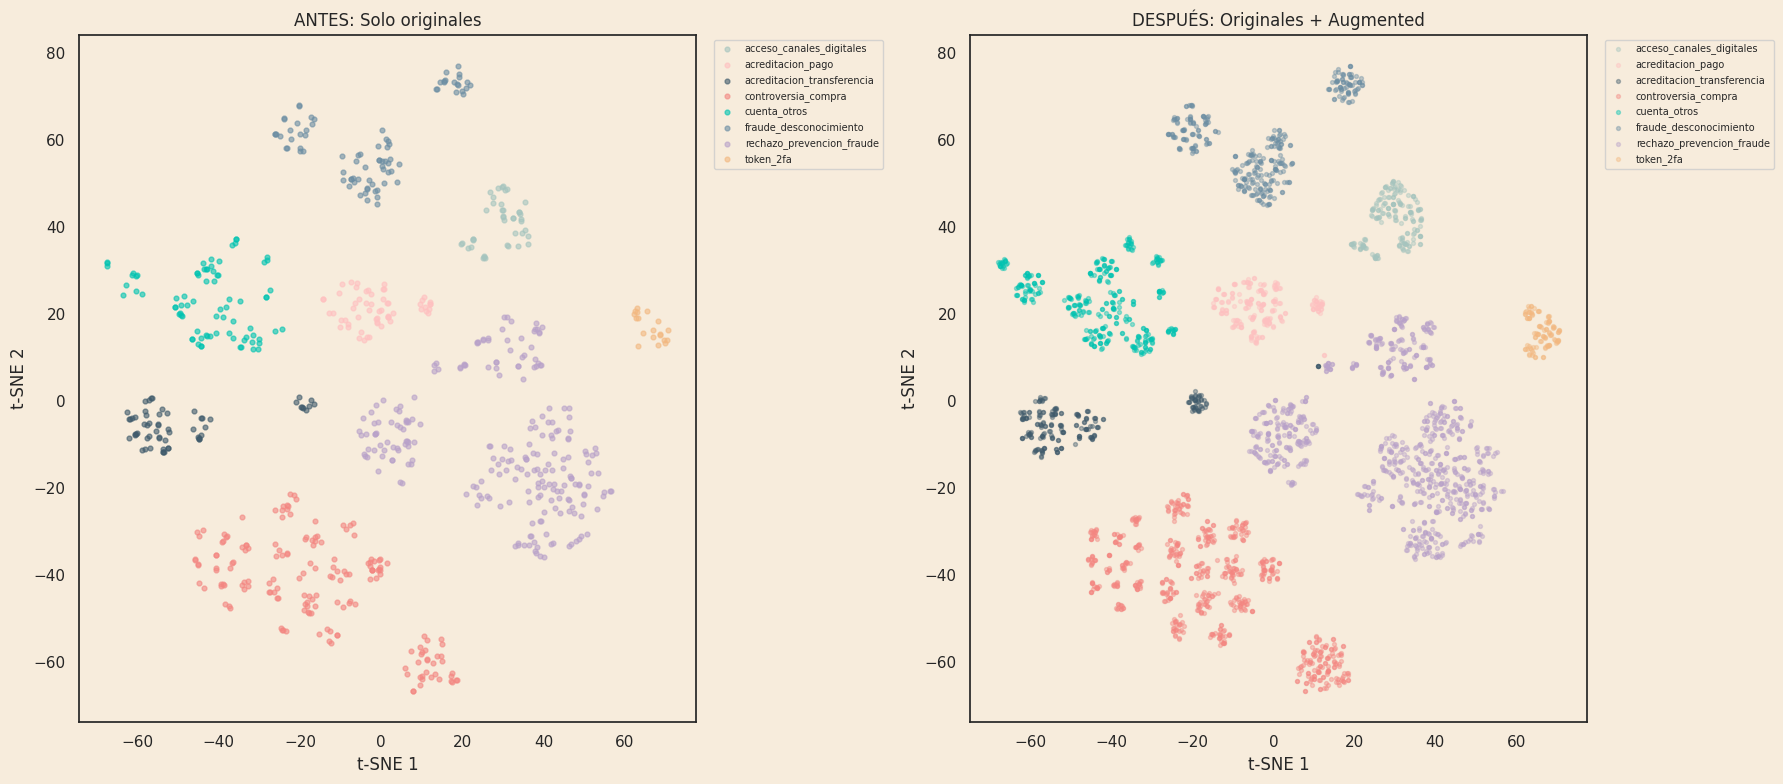

In [206]:
# Dataset combinado
train_original = train_convs_aug[["full_text", "intent_primary"]].copy()
train_original["source"] = "original"
train_aug_labeled = df_augmented[["full_text", "intent_primary"]].copy()
train_aug_labeled["source"] = "augmented"
combined = pd.concat([train_original, train_aug_labeled], ignore_index=True)

print(f"Total: {len(combined)} ({len(train_original)} orig + {len(train_aug_labeled)} aug)")

# Un solo pipeline para todo
X_comb_tsne, idx_s, _ = compute_tsne(
    combined["full_text"], n_sample=3000, seed=cfg.seed
)

intents_s = combined["intent_primary"].iloc[idx_s].values
sources_s = combined["source"].iloc[idx_s].values

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(cfg.fig_w * 2 + 2, cfg.fig_h * 2))

plot_tsne_scatter(X_comb_tsne, intents_s, axes[0],
                  "ANTES: Solo originales", cfg.palette,
                  mask=(sources_s == "original"))

plot_tsne_scatter(X_comb_tsne, intents_s, axes[1],
                  "DESPUÉS: Originales + Augmented", cfg.palette,
                  s=8, alpha=0.4)

plt.tight_layout()
plt.show()

### Efecto de la Augmentation sobre la Separabilidad

El t-SNE post-augmentation muestra clusters aun sin solapamiento en los
bordes por lo que no se logra el efecto querido de solapamiento entre datos.

Se podria utilizar LLMs para generar otras combinaciones de frases basadas en las ya generadas. Por ejemplo, agregar distintos tipos de tonos, y tipos de redacción, de esta forma buscar que haya mayor solapamiento entre las clases.

## Conclusiones del EDA

### Hallazgos principales

**1. Dataset bien estructurado para clasificación de intents.**
El dataset cuenta con 8,000 conversaciones en 8 intents,
con metadata rica (severidad, fraude, outcome, routing) que habilita tareas
multitask. La confianza de las entidades es alta y no hay valores nulos en
las tablas principales.

**2. Alta reutilización de frases — problema y solución.**
Solo ~3,271 textos únicos sobre ~46,713 mensajes generan data leakage
elevado con el split original (>50% de textos de test en train). Se buscó mitigarlo
aplicando un re-split por unicidad que prioriza conversaciones con vocabulario
diverso para val/test.

**3. Sobre-separabilidad sintética — problema y solución.**
El dataset sintético genera clusters TF-IDF excesivamente separados, lo que
favorece el overfitting léxico. Se aplicó Data Augmentation con técnicas EDA
(synonym replace, random swap, random deletion, random insertion) generando
3 variantes por conversación de entrenamiento, de igual forma no se logro superponer clases.

**4. intent_secondary no es viable.**
Con un 81%+ de valores nulos, esta columna queda descartada como objetivo
de clasificación. Se recomienda intent_primary como única etiqueta target.

### Recomendaciones detectadas para el modelado

- **Modelo base:** BERT en español (`dccuchile/bert-base-spanish-wwm-cased`)
  es adecuado dado que el dataset es monolingüe en español.
- **max_length:** 256 tokens cubre la totalidad del dataset sin truncamiento.
- **Input:** texto completo de la conversación concatenado con [SEP] entre turnos.


## Guardado dataset

In [207]:
def ensure_dir(path: str) -> None:
    """Crea el directorio si no existe."""
    os.makedirs(path, exist_ok=True)

def save_dataframes_to_csv(
    out_dir: str,
    conversations,
    messages,
    labels,
    entities,
    index: bool = False
) -> dict:
    """
    Guarda los dataframes en CSV con los nombres esperados.
    Devuelve un dict con paths generados.
    """
    ensure_dir(out_dir)

    paths = {
        "conversations": os.path.join(out_dir, "conversations.csv"),
        "messages": os.path.join(out_dir, "messages.csv"),
        "labels": os.path.join(out_dir, "labels.csv"),
        "entities": os.path.join(out_dir, "entities.csv"),
    }

    conversations.to_csv(paths["conversations"], index=index)
    messages.to_csv(paths["messages"], index=index)
    labels.to_csv(paths["labels"], index=index)
    entities.to_csv(paths["entities"], index=index)

    return paths

def zip_folder(
    folder_path: str,
    zip_path: str,
    include_root: bool = False
) -> None:
    """
    Crea un zip de todo el contenido de folder_path.
    - include_root=False: mete los archivos al root del zip (recomendado para tu caso)
    - include_root=True: incluye la carpeta contenedora dentro del zip
    """
    folder_path = os.path.abspath(folder_path)
    root_name = os.path.basename(folder_path)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(folder_path):
            for file in files:
                abs_file = os.path.join(root, file)
                rel = os.path.relpath(abs_file, folder_path)

                arcname = os.path.join(root_name, rel) if include_root else rel
                zf.write(abs_file, arcname=arcname)

def sanity_check_columns(original_df, modified_df, name: str) -> None:
    """
    Validación simple: mismas columnas (mismo set y orden).
    Ajustá si tu pipeline permite columnas nuevas.
    """
    if list(original_df.columns) != list(modified_df.columns):
        raise ValueError(
            f"Las columnas de '{name}' cambiaron.\n"
            f"Original: {list(original_df.columns)}\n"
            f"Nuevo:    {list(modified_df.columns)}"
        )

def build_training_zip(
    base_extract_dir: str,
    conversations,
    messages,
    labels,
    entities,
    zip_name_prefix: str = "claimstruct_multitable_v2_clean",
    validate_against_original: bool = False
) -> str:
    """
    Guarda CSVs modificados y genera un ZIP listo para entrenamiento.
    - base_extract_dir: donde está el dataset original extraído (para tomar referencia si validás)
    - validate_against_original: si True, valida columnas contra los CSV originales.
    Devuelve path al zip generado.
    """
    # Timestamp para versionado simple
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    out_dir = os.path.join("/content", f"{zip_name_prefix}_{stamp}")
    ensure_dir(out_dir)

    # Validación opcional contra originales
    if validate_against_original:
        orig_conversations = safe_read_csv(os.path.join(base_extract_dir, "conversations.csv"))
        orig_messages = safe_read_csv(os.path.join(base_extract_dir, "messages.csv"))
        orig_labels = safe_read_csv(os.path.join(base_extract_dir, "labels.csv"))
        orig_entities = safe_read_csv(os.path.join(base_extract_dir, "entities.csv"))

        sanity_check_columns(orig_conversations, conversations, "conversations")
        sanity_check_columns(orig_messages, messages, "messages")
        sanity_check_columns(orig_labels, labels, "labels")
        sanity_check_columns(orig_entities, entities, "entities")

    # Guardar CSVs
    paths = save_dataframes_to_csv(
        out_dir=out_dir,
        conversations=conversations,
        messages=messages,
        labels=labels,
        entities=entities,
        index=False
    )

    print("CSVs guardados:")
    for k, v in paths.items():
        print(f" - {k}: {v}")

    # Crear ZIP
    zip_path = os.path.join("/content", f"{zip_name_prefix}_{stamp}.zip")
    zip_folder(out_dir, zip_path, include_root=False)

    print(f"\nZIP generado: {zip_path}")
    return zip_path

In [208]:
zip_path = build_training_zip(
    base_extract_dir=extract_dir,
    conversations=conversations,
    messages=messages,
    labels=labels,
    entities=entities,
    zip_name_prefix="claimstruct_multitable_v2_for_training",
    validate_against_original=False
)

CSVs guardados:
 - conversations: /content/claimstruct_multitable_v2_for_training_20260226_023737/conversations.csv
 - messages: /content/claimstruct_multitable_v2_for_training_20260226_023737/messages.csv
 - labels: /content/claimstruct_multitable_v2_for_training_20260226_023737/labels.csv
 - entities: /content/claimstruct_multitable_v2_for_training_20260226_023737/entities.csv

ZIP generado: /content/claimstruct_multitable_v2_for_training_20260226_023737.zip
